# PCA de synthèse — montrer ce que disent les analyses

Condensé visuel des déterminants de la **conservation** d'une position d'actine.
Unité = une position canonique (résidu MAFFT).

**Verdict honnête des tendances (testé sur les données) :**

| affirmation | verdict | chiffre |
|---|---|---|
| enfoui (rsa bas) = plus conservé | ✅ **fort** | rho = **−0.45** (p=2e-20) |
| buried ASA% moyen ↑ = mieux conservé | ✅ faible | rho = +0.17, +0.07 à rsa égal |
| + d'ABP différents ≠ + conservé | ✅ confirmé | brut −0.22 → **+0.13 à rsa égal** (ns) |
| hydrophobe = plus conservé | ❌ **non** | rho = −0.02 (ns) |
| aromatique = plus conservé | ⚠️ tendance ns | 4.54 vs 4.18, p=0.10 (n=31) |

→ **Le déterminant dominant est l'enfouissement.** Le reste (nb de partenaires, hydrophobicité) n'ajoute rien une fois l'exposition contrôlée.

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import svd
from scipy.stats import spearmanr, mannwhitneyu
from pathlib import Path
_R = Path('..') if (Path('..')/'data').exists() else Path('.')

cv  = pd.read_csv(_R/'data/proteocast/conservation_vs_asa_per_position.csv').set_index('canon')
df3 = pd.read_csv(_R/'data/filtered/details/3.interface_residues.csv')
di  = pd.read_csv(_R/'data/filtered/details/1.interactions.csv')
da  = pd.read_csv(_R/'data/filtered/filtered_all_data.csv', low_memory=False)
pp  = pd.read_csv(_R/'data/filtered/proteins_per_pdb.csv'); ac = set(pp[pp.is_actin]['chain'].str.lower())

df3['canon'] = pd.to_numeric(df3['residue_number_canon_mafft'], errors='coerce')
df3['pct']   = pd.to_numeric(df3['buried_ASA_percent'].astype(str).str.replace('%','',regex=False), errors='coerce')
homo = set(di[di['chain_B_id'].str.lower().isin(ac)]['interaction_id'])
d = df3.dropna(subset=['canon']).copy(); d['canon'] = d.canon.astype(int)
d['aa'] = d['residue_name'].astype(str).str.upper().str.strip()

# acide amine majoritaire par position -> hydrophobicite (Kyte-Doolittle) + aromaticite
KD = {'A':1.8,'R':-4.5,'N':-3.5,'D':-3.5,'C':2.5,'Q':-3.5,'E':-3.5,'G':-0.4,'H':-3.2,'I':4.5,
      'L':3.8,'K':-3.9,'M':1.9,'F':2.8,'P':-1.6,'S':-0.8,'T':-0.7,'W':-0.9,'Y':-1.3,'V':4.2}
aa_can = d[d.aa.str.len()==1].groupby('canon')['aa'].agg(lambda s: s.mode().iloc[0])
cv['aa']             = aa_can.reindex(cv.index)
cv['hydrophobicite'] = cv['aa'].map(KD)
cv['aromatique']     = cv['aa'].isin(list('FWY')).astype(float)

# descripteurs d'interface cote actine (hetero)
het = d[~d.interaction_id.isin(homo)]
cv['asa_mean'] = het.groupby('canon')['pct'].mean().reindex(cv.index)     # buried ASA% moyen
mm = di.merge(da[['subunit_1','subunit_2','s2_sequence_cluster_40','s2_sequence_cluster_70']].drop_duplicates(),
              left_on=['chain_A_id','chain_B_id'], right_on=['subunit_1','subunit_2'], how='left')
cv['n_fam'] = het.assign(f=het.interaction_id.map(mm.set_index('interaction_id')['s2_sequence_cluster_40'])).groupby('canon')['f'].nunique().reindex(cv.index).fillna(0)
cv['n_abp'] = het.assign(f=het.interaction_id.map(mm.set_index('interaction_id')['s2_sequence_cluster_70'])).groupby('canon')['f'].nunique().reindex(cv.index).fillna(0)

P = cv
print(f'{len(P)} positions | descripteurs prets')
P[['conservation','rsa','asa_mean','combined_asa','homo_asa','hetero_asa','n_fam','n_abp','hydrophobicite','aromatique']].describe().round(2)

375 positions | descripteurs prets


,conservation,rsa,asa_mean,combined_asa,homo_asa,hetero_asa,n_fam,n_abp,hydrophobicite,aromatique
count,375.00,374.00,375.00,375.00,375.00,375.00,375.00,375.00,375.00,375.00
mean,4.21,0.25,44.03,21.22,11.57,12.95,12.81,13.89,-0.87,0.08
std,1.19,0.22,15.23,22.47,24.65,10.24,8.02,8.89,3.04,0.28
min,1.26,0.00,3.25,0.00,0.00,0.00,1.00,1.00,-4.50,0.00
25%,3.39,0.04,33.77,6.07,0.00,4.04,7.00,8.00,-3.50,0.00
50%,4.29,0.19,42.99,15.66,0.00,12.84,11.00,12.00,-1.30,0.00
75%,5.10,0.42,53.31,26.59,2.38,18.92,16.00,17.00,1.80,0.00
max,6.95,0.86,91.93,98.56,98.56,50.00,40.00,44.00,4.50,1.00


# A — PCA des positions d'actine

Un point = **une position canonique** de l'actine. Message central : la conservation suit l'**enfouissement**, pas le nombre/type de partenaires.

## Figure 1 — Cercle des corrélations (le message en une image)

PCA sur les variables, conservation incluse. Flèches dans le **même sens** = corrélées ;
**opposées** = anti-corrélées ; **perpendiculaires** = indépendantes.
🔴 conservation · 🔵 exposition (rsa, nb familles, enfoui ABP) · 🟢 enfouissement.

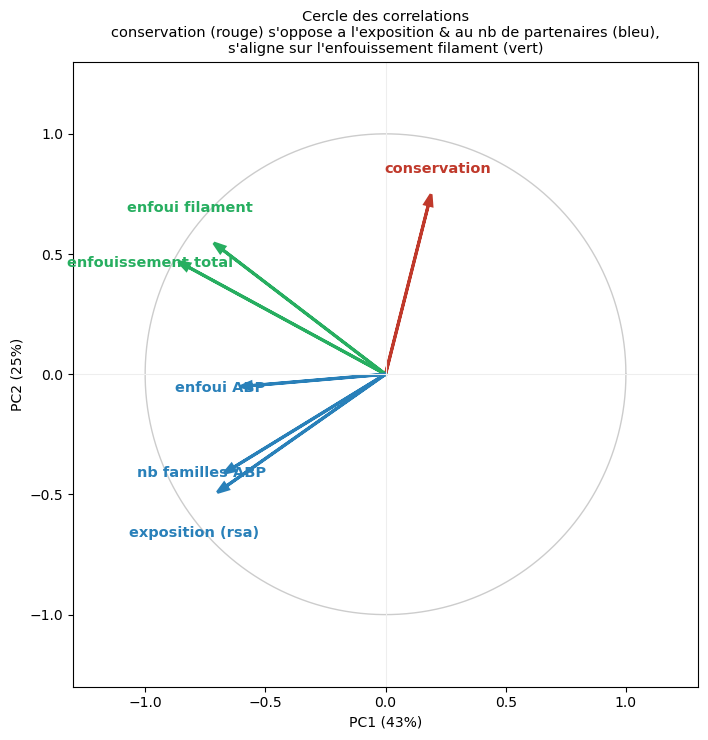

In [2]:
vlab = {'conservation':'conservation','rsa':'exposition (rsa)','combined_asa':'enfouissement total',
        'homo_asa':'enfoui filament','hetero_asa':'enfoui ABP','n_fam':'nb familles ABP'}
grp  = {'conservation':'cons','rsa':'expo','n_fam':'expo','hetero_asa':'expo','combined_asa':'bury','homo_asa':'bury'}
gcol = {'cons':'#c0392b','expo':'#2980b9','bury':'#27ae60'}
feat = list(vlab); Q = P.dropna(subset=feat).copy()
X = Q[feat].values.astype(float); Xz = (X-X.mean(0))/(X.std(0)+1e-9)
U,S,Vt = svd(Xz, full_matrices=False); ev = (S**2)/np.sum(S**2); load = Vt.T*np.sqrt((S**2)/len(Q))

fig,ax = plt.subplots(figsize=(7.5,7.5)); th=np.linspace(0,2*np.pi,200)
ax.plot(np.cos(th),np.sin(th),color='#ccc',lw=1); ax.axhline(0,color='#eee',lw=.8); ax.axvline(0,color='#eee',lw=.8)
dy={'rsa':-0.10,'n_fam':+0.06,'homo_asa':+0.07,'combined_asa':-0.07}
for i,f in enumerate(feat):
    c=gcol[grp[f]]
    ax.arrow(0,0,load[i,0],load[i,1],head_width=.03,color=c,lw=2.2,length_includes_head=True)
    ax.text(load[i,0]*1.14,load[i,1]*1.14+dy.get(f,0),vlab[f],color=c,fontsize=10.5,ha='center',va='center',fontweight='bold')
ax.set_xlim(-1.3,1.3); ax.set_ylim(-1.3,1.3); ax.set_aspect('equal')
ax.set_xlabel(f'PC1 ({ev[0]*100:.0f}%)'); ax.set_ylabel(f'PC2 ({ev[1]*100:.0f}%)')
ax.set_title("Cercle des correlations\nconservation (rouge) s'oppose a l'exposition & au nb de partenaires (bleu),\ns'aligne sur l'enfouissement filament (vert)",fontsize=10.5)
plt.tight_layout(); plt.show()

## Figure 2 — PCA des positions, conservation en *overlay*

PCA sur descripteurs **structuraux seuls** (conservation exclue), points colorés ensuite.
Le gradient **conservation** est l'**inverse** des gradients `rsa`/`n_fam` → la conservation suit l'axe d'exposition.

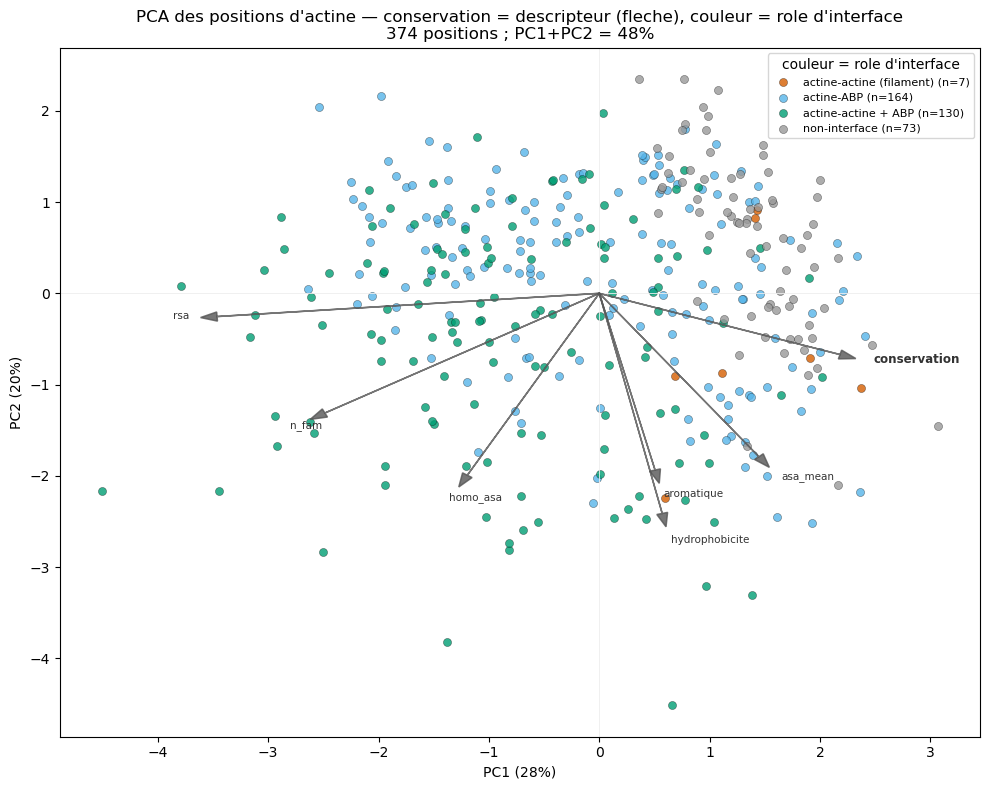

374 positions | categories: {'actine-ABP': 164, 'actine-actine + ABP': 130, 'non-interface': 73, 'actine-actine (filament)': 7}


In [3]:
# === PCA des positions d'actine — conservation INCLUSE comme descripteur ; couleur = role d'interface ===
# Non circulaire : la couleur (categorie d'interface) n'est pas la conservation.
sfeat = ['conservation','rsa','asa_mean','homo_asa','n_fam','hydrophobicite','aromatique']  # hetero_asa retire (asa_mean = enfouissement actine cote ABP)
def _catpos(r):
    if not r['at_interface']: return 'non-interface'
    if r['at_homo'] and r['at_hetero']: return 'actine-actine + ABP'
    if r['at_hetero']: return 'actine-ABP'
    if r['at_homo']: return 'actine-actine (filament)'
    return 'autre'
P['_cat']=P.apply(_catpos,axis=1)
R = P.dropna(subset=sfeat).copy()
Xs=R[sfeat].values.astype(float); Xsz=(Xs-Xs.mean(0))/(Xs.std(0)+1e-9)
from numpy.linalg import svd as _svd
Us,Ss,Vts=_svd(Xsz-Xsz.mean(0),full_matrices=False); pcs=Us*Ss; evs=(Ss**2)/np.sum(Ss**2)
_cor=np.array([[np.corrcoef(Xsz[:,j],pcs[:,k])[0,1] for k in range(2)] for j in range(len(sfeat))])

from matplotlib.lines import Line2D
_catcol={'actine-actine (filament)':'#D55E00','actine-ABP':'#56B4E9','actine-actine + ABP':'#009E73','non-interface':'#999999'}
_order=['actine-actine (filament)','actine-ABP','actine-actine + ABP','non-interface']
fig,ax=plt.subplots(figsize=(10,8))
for g in _order:
    m=(R['_cat']==g).values
    if mc:=m.any():
        ax.scatter(pcs[m,0],pcs[m,1],c=_catcol[g],s=34,edgecolor='k',lw=.25,alpha=.8,label=f'{g} (n={int(m.sum())})',zorder=2)
_f=0.8*np.abs(pcs).max()/np.abs(_cor).max()
for j,nm in enumerate(sfeat):
    _isc=(nm=='conservation')
    ax.arrow(0,0,_cor[j,0]*_f,_cor[j,1]*_f,color='#555',head_width=.10,lw=1.1,length_includes_head=True,alpha=.8,zorder=3)
    ax.annotate(nm,(_cor[j,0]*_f*1.07,_cor[j,1]*_f*1.07),fontsize=(8.5 if _isc else 7.5),
                color='#333',fontweight=('bold' if _isc else 'normal'),zorder=6)
ax.axhline(0,color='#eee',lw=.6); ax.axvline(0,color='#eee',lw=.6)
ax.set_xlabel(f'PC1 ({evs[0]*100:.0f}%)'); ax.set_ylabel(f'PC2 ({evs[1]*100:.0f}%)')
ax.legend(loc='best',fontsize=8,title='couleur = role d\'interface')
ax.set_title("PCA des positions d'actine — conservation = descripteur (fleche), couleur = role d'interface\n"
             f"{len(R)} positions ; PC1+PC2 = {(evs[0]+evs[1])*100:.0f}%")
plt.tight_layout(); plt.show()
print(f"{len(R)} positions | categories: {R['_cat'].value_counts().to_dict()}")


### Variante — positions, COEUR (>25% ASA)\n\nasa_mean et n_fam recalcules sur les seuls contacts ABP enfouis > 25% ASA.

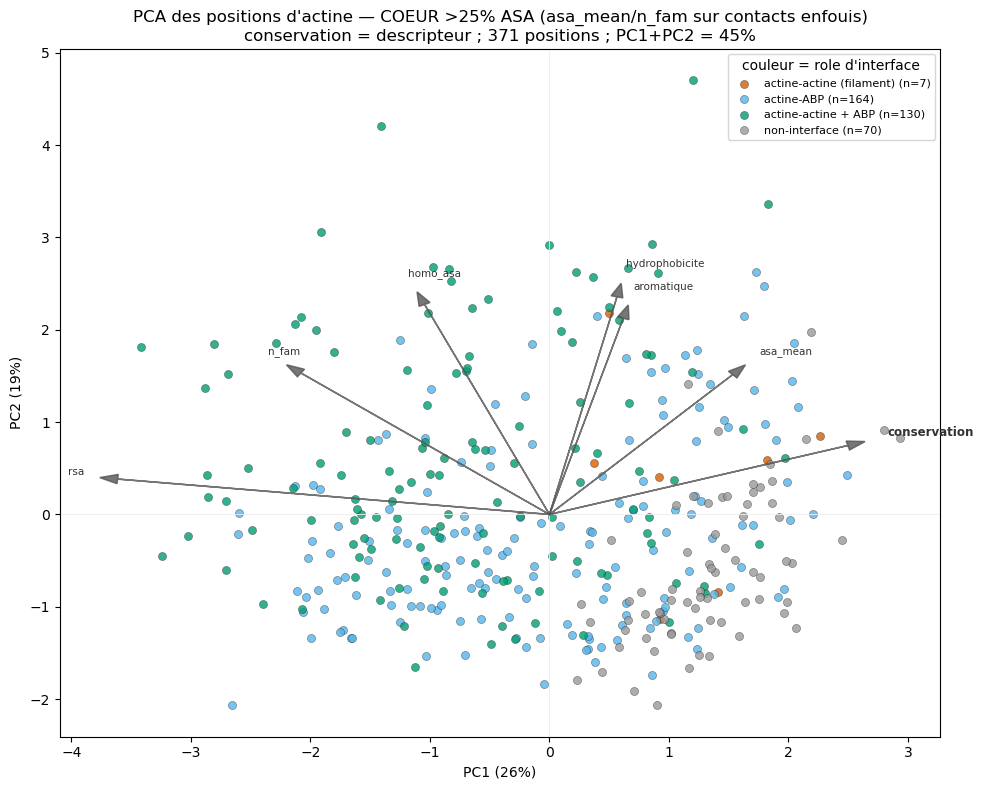

371 positions (coeur) | categories: {'actine-ABP': 164, 'actine-actine + ABP': 130, 'non-interface': 70, 'actine-actine (filament)': 7}


In [4]:
# === PCA des positions — COEUR (>25% ASA) : asa_mean et n_fam recalcules sur contacts enfouis ===
from pathlib import Path as _Pp
_Rp=_Pp('..') if (_Pp('..')/'data').exists() else _Pp('.')
_f3p=pd.read_csv(_Rp/'data/filtered/details/3.interface_residues.csv')
_dip=pd.read_csv(_Rp/'data/filtered/details/1.interactions.csv')
_dap=pd.read_csv(_Rp/'data/filtered/filtered_all_data.csv',low_memory=False)
_ppp=pd.read_csv(_Rp/'data/filtered/proteins_per_pdb.csv'); _acp=set(_ppp[_ppp.is_actin]['chain'].str.lower())
_f3p['pct']=pd.to_numeric(_f3p['buried_ASA_percent'].astype(str).str.replace('%','',regex=False),errors='coerce')
_f3p['canon']=pd.to_numeric(_f3p['residue_number_canon_mafft'],errors='coerce')
_homop=set(_dip[_dip['chain_B_id'].str.lower().isin(_acp)]['interaction_id'])
_dp=_f3p.dropna(subset=['canon','pct']).copy(); _dp['canon']=_dp.canon.astype(int)
_hetp=_dp[(~_dp.interaction_id.isin(_homop))&(_dp['pct']>25)]      # COEUR : contacts hetero enfouis >25%
_mp=_dip.merge(_dap[['subunit_1','subunit_2','s2_sequence_cluster_40']].drop_duplicates(),
               left_on=['chain_A_id','chain_B_id'],right_on=['subunit_1','subunit_2'],how='left')
Pc=P.copy()
Pc['asa_mean']=_hetp.groupby('canon')['pct'].mean().reindex(Pc.index)
Pc['n_fam']=_hetp.assign(f=_hetp.interaction_id.map(_mp.set_index('interaction_id')['s2_sequence_cluster_40'])).groupby('canon')['f'].nunique().reindex(Pc.index).fillna(0)

sfeat=['conservation','rsa','asa_mean','homo_asa','n_fam','hydrophobicite','aromatique']  # hetero_asa retire
R=Pc.dropna(subset=sfeat).copy()
Xs=R[sfeat].values.astype(float); Xsz=(Xs-Xs.mean(0))/(Xs.std(0)+1e-9)
from numpy.linalg import svd as _svd
Us,Ss,Vts=_svd(Xsz-Xsz.mean(0),full_matrices=False); pcs=Us*Ss; evs=(Ss**2)/np.sum(Ss**2)
_cor=np.array([[np.corrcoef(Xsz[:,j],pcs[:,k])[0,1] for k in range(2)] for j in range(len(sfeat))])
from matplotlib.lines import Line2D
_catcol={'actine-actine (filament)':'#D55E00','actine-ABP':'#56B4E9','actine-actine + ABP':'#009E73','non-interface':'#999999'}
_order=['actine-actine (filament)','actine-ABP','actine-actine + ABP','non-interface']
fig,ax=plt.subplots(figsize=(10,8))
for g in _order:
    m=(R['_cat']==g).values
    if m.any():
        ax.scatter(pcs[m,0],pcs[m,1],c=_catcol[g],s=34,edgecolor='k',lw=.25,alpha=.8,label=f'{g} (n={int(m.sum())})',zorder=2)
_f=0.8*np.abs(pcs).max()/np.abs(_cor).max()
for j,nm in enumerate(sfeat):
    _isc=(nm=='conservation')
    ax.arrow(0,0,_cor[j,0]*_f,_cor[j,1]*_f,color='#555',head_width=.10,lw=1.1,length_includes_head=True,alpha=.8,zorder=3)
    ax.annotate(nm,(_cor[j,0]*_f*1.07,_cor[j,1]*_f*1.07),fontsize=(8.5 if _isc else 7.5),color='#333',fontweight=('bold' if _isc else 'normal'),zorder=6)
ax.axhline(0,color='#eee',lw=.6); ax.axvline(0,color='#eee',lw=.6)
ax.set_xlabel(f'PC1 ({evs[0]*100:.0f}%)'); ax.set_ylabel(f'PC2 ({evs[1]*100:.0f}%)')
ax.legend(loc='best',fontsize=8,title="couleur = role d'interface")
ax.set_title("PCA des positions d'actine — COEUR >25% ASA (asa_mean/n_fam sur contacts enfouis)\n"
             f"conservation = descripteur ; {len(R)} positions ; PC1+PC2 = {(evs[0]+evs[1])*100:.0f}%")
plt.tight_layout(); plt.show()
print(f"{len(R)} positions (coeur) | categories: {R['_cat'].value_counts().to_dict()}")


## Figure 3 — Tableau de bord des déterminants (brut vs à exposition égale)

Pour chaque descripteur : corrélation de Spearman avec la conservation, **brute** et **à rsa égal**
(résidualisation = on enlève l'effet de l'exposition). C'est la preuve directe, descripteur par descripteur.
Une barre qui **change de signe** entre brut et « à rsa égal » = effet porté par l'exposition (artefact).

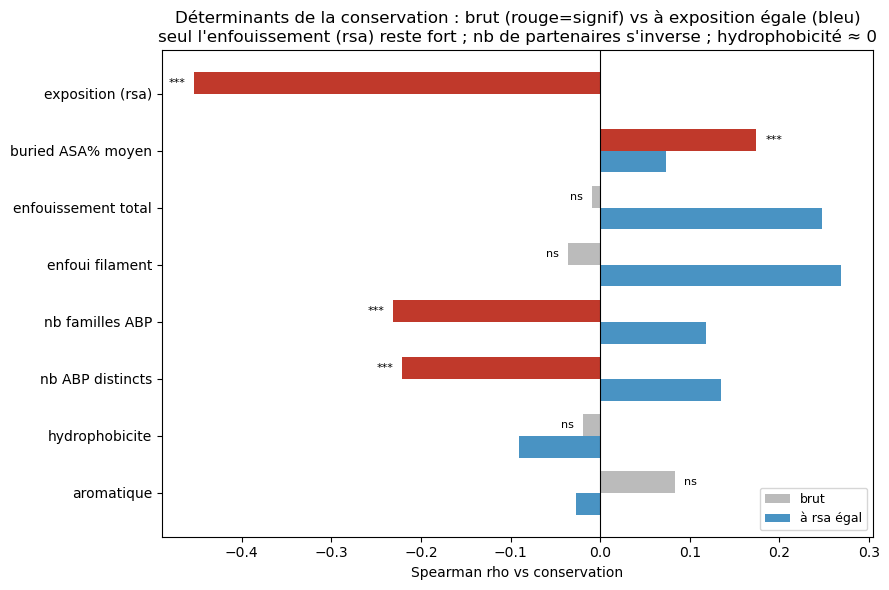

                lab   brut     p  partial
         aromatique  0.084 0.104   -0.027
     hydrophobicite -0.019 0.715   -0.090
   nb ABP distincts -0.221 0.000    0.135
    nb familles ABP -0.231 0.000    0.118
    enfoui filament -0.036 0.487    0.269
enfouissement total -0.009 0.857    0.248
  buried ASA% moyen  0.174 0.001    0.074
   exposition (rsa) -0.453 0.000      NaN


In [5]:
def _resid(a,b):
    b=np.c_[np.ones(len(b)),b]; return a-b@np.linalg.lstsq(b,a,rcond=None)[0]
def rho_partial(col):
    s=P.dropna(subset=[col,'conservation','rsa'])
    return spearmanr(_resid(s[col].values,s['rsa'].values),_resid(s['conservation'].values,s['rsa'].values))[0]
def rho_brut(col):
    s=P.dropna(subset=[col,'conservation']); r,p=spearmanr(s[col],s['conservation']); return r,p

descr=[('rsa','exposition (rsa)'),('asa_mean','buried ASA% moyen'),('combined_asa','enfouissement total'),
       ('homo_asa','enfoui filament'),('n_fam','nb familles ABP'),('n_abp','nb ABP distincts'),
       ('hydrophobicite','hydrophobicite'),('aromatique','aromatique')]
rows=[]
for col,lab in descr:
    rb,pb=rho_brut(col); rp=(np.nan if col=='rsa' else rho_partial(col))
    rows.append((lab,rb,pb,rp))
T=pd.DataFrame(rows,columns=['lab','brut','p','partial']).iloc[::-1]
fig,ax=plt.subplots(figsize=(9,6)); y=np.arange(len(T)); h=0.38
cb=['#c0392b' if p<0.05 else '#bbbbbb' for p in T['p']]
ax.barh(y+h/2,T['brut'],height=h,color=cb,label='brut')
ax.barh(y-h/2,T['partial'],height=h,color='#2980b9',alpha=.85,label='à rsa égal')
for i,(_,r) in enumerate(T.iterrows()):
    s='***' if r['p']<1e-3 else '**' if r['p']<1e-2 else '*' if r['p']<.05 else 'ns'
    ax.text(r['brut']+(0.01 if r['brut']>=0 else -0.01),i+h/2,s,va='center',ha='left' if r['brut']>=0 else 'right',fontsize=8)
ax.set_yticks(y); ax.set_yticklabels(T['lab']); ax.axvline(0,color='k',lw=.8)
ax.set_xlabel('Spearman rho vs conservation'); ax.legend(loc='lower right',fontsize=9)
ax.set_title("Déterminants de la conservation : brut (rouge=signif) vs à exposition égale (bleu)\nseul l'enfouissement (rsa) reste fort ; nb de partenaires s'inverse ; hydrophobicité ≈ 0")
plt.tight_layout(); plt.show()
print(T.round(3).to_string(index=False))

# B — PCA des interfaces

Un point = **un cluster d'interface C70**. Montre que les interfaces ont des **profils physico-chimiques différents**.

## Figure 4 — PCA des interfaces : les clusters diffèrent en physico-chimie (claim 6)

Ici un point = un **cluster d'interface C70** (≥ 3 interactions), décrit par la physico-chimie
de ses résidus d'actine (hydrophobicité, charges +/−, aromaticité, enfouissement). Couleur =
conservation moyenne du cluster, taille = nb d'interactions. Si les points **s'étalent** (pas un
seul nuage compact), c'est que les interfaces n'ont **pas le même profil physico-chimique**.

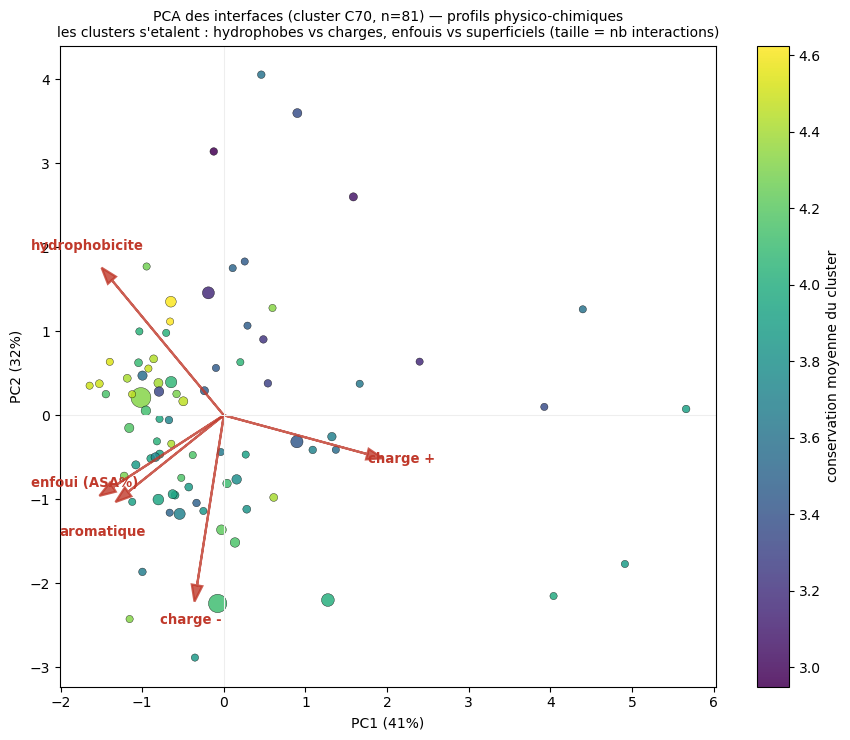

81 clusters | etendue hydrophobicite -2.6..0.9 | charge+ 0.05..0.62 | enfoui 20..56%


In [6]:
# === PCA des interfaces C70 : profils physico-chimiques cote actine ===
_cons = P['conservation']
_m = di.merge(da[['subunit_1','subunit_2','s2_actine','cluster_data_70']].drop_duplicates(),
              left_on=['chain_A_id','chain_B_id'], right_on=['subunit_1','subunit_2'], how='left')
_m['s2_actine'] = _m['s2_actine'].fillna(False).astype(bool)
_het = _m[~_m.s2_actine].dropna(subset=['cluster_data_70'])
_f3 = df3.copy()
_f3['aa']  = _f3['residue_name'].astype(str).str.upper().str.strip()
_f3['c70'] = _f3.interaction_id.map(_het.set_index('interaction_id')['cluster_data_70'])
_f3['act'] = _f3.interaction_id.map(_het.set_index('interaction_id')['chain_A_id'].str.lower())
_a = _f3[(_f3.chain.str.lower()==_f3.act) & _f3.c70.notna() & (_f3.aa.str.len()==1)].copy()
_a['kd']=_a.aa.map(KD); _a['pos']=_a.aa.isin(list('KR')); _a['neg']=_a.aa.isin(list('DE'))
_a['aro']=_a.aa.isin(list('FWY')); _a['cons']=_a.canon.map(_cons)
_g = _a.groupby('c70')
desc = pd.DataFrame({'hydrophobicite':_g['kd'].mean(),'charge +':_g['pos'].mean(),'charge -':_g['neg'].mean(),
                     'aromatique':_g['aro'].mean(),'enfoui (ASA%)':_g['pct'].mean(),
                     'conservation':_g['cons'].mean(),'n_intx':_g['interaction_id'].nunique()})
desc = desc[desc.n_intx>=3]
ifeat=['hydrophobicite','charge +','charge -','aromatique','enfoui (ASA%)']
Xi=desc[ifeat].values; Xiz=(Xi-Xi.mean(0))/(Xi.std(0)+1e-9)
Ui,Si,Vti=np.linalg.svd(Xiz,full_matrices=False); pci=Ui*Si; evi=(Si**2)/np.sum(Si**2)

fig,ax=plt.subplots(figsize=(9,7.5))
sc=ax.scatter(pci[:,0],pci[:,1],c=desc['conservation'],cmap='viridis',
              s=20+desc['n_intx']*2.5,edgecolor='k',lw=.3,alpha=.85)
fig.colorbar(sc,ax=ax,label='conservation moyenne du cluster')
_off={'aromatique':(0,-0.28),'enfoui (ASA%)':(0,0.22)}   # decalage anti-chevauchement
for i,f in enumerate(ifeat):
    ax.arrow(0,0,Vti[0,i]*3.2,Vti[1,i]*3.2,color='#c0392b',head_width=.13,lw=1.6,length_includes_head=True,alpha=.8)
    ox,oy=_off.get(f,(0,0))
    ax.text(Vti[0,i]*3.2*1.12+ox,Vti[1,i]*3.2*1.12+oy,f,color='#c0392b',fontsize=9.5,ha='center',fontweight='bold')
ax.axhline(0,color='#eee',lw=.8); ax.axvline(0,color='#eee',lw=.8)
ax.set_xlabel(f'PC1 ({evi[0]*100:.0f}%)'); ax.set_ylabel(f'PC2 ({evi[1]*100:.0f}%)')
ax.set_title(f"PCA des interfaces (cluster C70, n={len(desc)}) — profils physico-chimiques\n"
             "les clusters s'etalent : hydrophobes vs charges, enfouis vs superficiels (taille = nb interactions)",fontsize=10)
plt.tight_layout(); plt.show()
print(f"{len(desc)} clusters | etendue hydrophobicite {desc['hydrophobicite'].min():.1f}..{desc['hydrophobicite'].max():.1f} "
      f"| charge+ {desc['charge +'].min():.2f}..{desc['charge +'].max():.2f} | enfoui {desc['enfoui (ASA%)'].min():.0f}..{desc['enfoui (ASA%)'].max():.0f}%")

### Vue détaillée — PCA des interfaces C70 (actine S1 + partenaire S2, homo vs hétéro)

222 clusters d'interface C70 (19 homo / 203 hetero)
Variance PC1+PC2 = 25% + 17% = 42%
Silhouette separation homo vs hetero = -0.081  (~0 -> interfaces homo non distinctes des hetero)


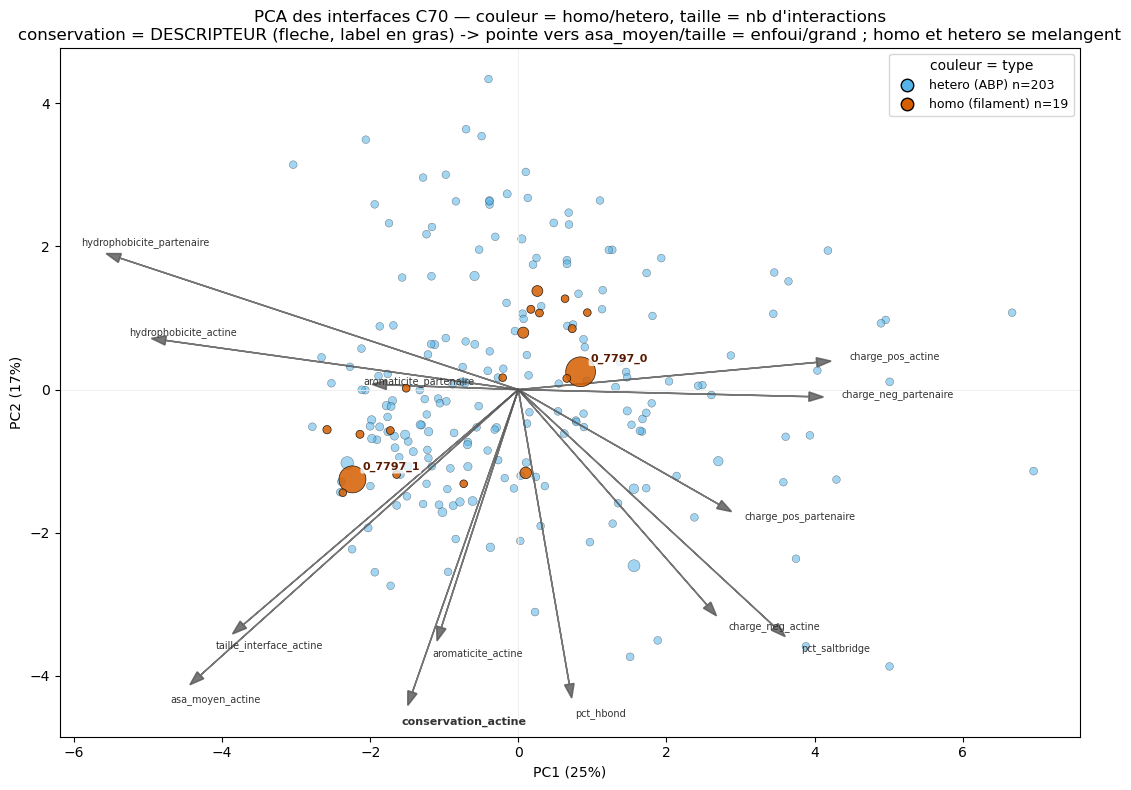

In [7]:
# === PCA des interfaces au niveau cluster C70 (homo + hetero) ===
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path as _P
from scipy.spatial.distance import pdist, squareform
_R = _P('..') if _P('../data').exists() else _P('.')
_df3=pd.read_csv(_R/'data/filtered/details/3.interface_residues.csv')
_df3['pct']=pd.to_numeric(_df3['buried_ASA_percent'].astype(str).str.replace('%','',regex=False),errors='coerce')
_df3['a2']=pd.to_numeric(_df3['buried_ASA_Å²'].astype(str).str.replace('<0.1','0.05',regex=False),errors='coerce')
_df3['canon']=pd.to_numeric(_df3['residue_number_canon_mafft'],errors='coerce')
_df3=_df3[_df3.canon.notna()&_df3.pct.notna()].copy()
_di=pd.read_csv(_R/'data/filtered/details/1.interactions.csv')
_da=pd.read_csv(_R/'data/filtered/filtered_all_data.csv',low_memory=False)
_m=_di.merge(_da[['subunit_1','subunit_2','subunit_2_title','s2_actine','cluster_data_70']].drop_duplicates(),
             left_on=['chain_A_id','chain_B_id'],right_on=['subunit_1','subunit_2'],how='left').drop_duplicates('interaction_id')
_m=_m.dropna(subset=['cluster_data_70'])
_m['homo']=_m['s2_actine'].fillna(False).astype(bool)
_m['abp_title']=_m['subunit_2_title'].fillna('?').astype(str).str.replace(r'\s*\(.*?\)','',regex=True).str.strip().str[:22]
_clu2abp=_m[~_m['homo']].groupby('cluster_data_70')['abp_title'].agg(lambda x:x.value_counts().index[0])
_m['interface_area']=pd.to_numeric(_m['interface_area'].astype(str).str.replace('Å²','',regex=False).str.strip(),errors='coerce')
for _c in ['num_hbonds','num_salt_bridges','num_contacts']: _m[_c]=pd.to_numeric(_m[_c],errors='coerce')
_imap=_m.set_index('interaction_id'); _chA=_imap['chain_A_id'].str.lower(); _clu=_imap['cluster_data_70']
_d=_df3[_df3.interaction_id.isin(set(_m.interaction_id))].copy()
_d['_a']=_d.interaction_id.map(_chA); _d=_d[_d.chain.str.lower()==_d._a].copy()   # cote actine = chaine A (subunit_1)
_d['clu']=_d.interaction_id.map(_clu); _d['canon']=_d.canon.astype(int)
_cdf=pd.read_csv(_R/'data/proteocast/conservation_vs_asa_per_position.csv'); _cons=dict(zip(_cdf['canon'].astype(int),_cdf['conservation']))
_clsmap=dict(zip(_cdf['canon'].astype(int),_cdf['residue_class']))   # canon -> sensitive/tolerant
_KD={'A':1.8,'R':-4.5,'N':-3.5,'D':-3.5,'C':2.5,'Q':-3.5,'E':-3.5,'G':-0.4,'H':-3.2,'I':4.5,'L':3.8,'K':-3.9,'M':1.9,'F':2.8,'P':-1.6,'S':-0.8,'T':-0.7,'W':-0.9,'Y':-1.3,'V':4.2}
def _md(s): mm=s.mode(); return mm.iloc[0] if len(mm) else None
_po=_d.groupby(['clu','canon']).agg(w=('pct','mean'),res=('residue_name',_md)).reset_index()
_po['kd']=_po['res'].map(lambda r:_KD.get(str(r),0.0)); _po['cons']=_po['canon'].map(lambda c:_cons.get(int(c),np.nan))
_po['ispos']=_po['res'].isin({'R','K'}).astype(float); _po['isneg']=_po['res'].isin({'D','E'}).astype(float); _po['isaro']=_po['res'].isin({'F','Y','W'}).astype(float)
def _wmi(g,c):
    w=g['w'].values; x=g[c].values; mk=~np.isnan(x)
    return (w[mk]*x[mk]).sum()/w[mk].sum() if w[mk].sum()>0 else np.nan
Fi=_po.groupby('clu').apply(lambda g:pd.Series({'conservation_actine':_wmi(g,'cons'),'hydrophobicite_actine':_wmi(g,'kd'),
    'charge_pos_actine':_wmi(g,'ispos'),'charge_neg_actine':_wmi(g,'isneg'),'aromaticite_actine':_wmi(g,'isaro'),'asa_moyen_actine':_wmi(g,'w')}))
Fi['n_residus']=_d.groupby('interaction_id').size().groupby(_clu).mean()
_ag=_m.groupby('cluster_data_70').agg(hb=('num_hbonds','sum'),sb=('num_salt_bridges','sum'),
    ct=('num_contacts','sum'),n=('interaction_id','nunique'),homo=('homo','mean'))
Fi['taille_interface_actine']=_d.groupby('interaction_id')['a2'].sum().groupby(_clu).mean()
Fi=Fi.join(_ag[['homo']])
_cc=pd.read_csv(_R/'data/filtered/details/4.inter-residue_contacts.csv'); _CHG={'R':1,'K':1,'D':-1,'E':-1}
_cc=_cc[_cc.interaction_id.isin(set(_m.interaction_id))].copy(); _cc['_clu']=_cc.interaction_id.map(_clu)
_cc['charge_compl']=-(_cc['residue_A_name'].map(lambda r:_CHG.get(str(r),0))*_cc['residue_B_name'].map(lambda r:_CHG.get(str(r),0)))
Fi['charge_compl']=_cc.groupby('_clu')['charge_compl'].mean()
Fi['pct_hbond']=100*_ag['hb']/_ag['ct']; Fi['pct_saltbridge']=100*_ag['sb']/_ag['ct']
# --- descripteurs cote PARTENAIRE (chaine B = S2 ; actine pour homo, ABP pour hetero) ---
_chB=_imap['chain_B_id'].str.lower()
_db=_df3[_df3.interaction_id.isin(set(_m.interaction_id))].copy()
_db['_b']=_db.interaction_id.map(_chB); _db=_db[_db.chain.str.lower()==_db._b].copy()
_db['clu']=_db.interaction_id.map(_clu)
_db['kd']=_db['residue_name'].map(lambda r:_KD.get(str(r),0.0))
_db['ispos']=_db['residue_name'].isin({'R','K'}).astype(float)
_db['isneg']=_db['residue_name'].isin({'D','E'}).astype(float)
_db['isaro']=_db['residue_name'].isin({'F','Y','W'}).astype(float)
def _wmb(g,col):
    w=g['pct'].values; x=g[col].values; mk=~np.isnan(x)
    return (w[mk]*x[mk]).sum()/w[mk].sum() if w[mk].sum()>0 else np.nan
Fb=_db.groupby('clu').apply(lambda g:pd.Series({'hydrophobicite_partenaire':_wmb(g,'kd'),
    'charge_pos_partenaire':_wmb(g,'ispos'),'charge_neg_partenaire':_wmb(g,'isneg'),'aromaticite_partenaire':_wmb(g,'isaro'),'asa_moyen_partenaire':g['pct'].mean()}))
Fi=Fi.join(Fb)
_featI=['conservation_actine','hydrophobicite_actine','charge_pos_actine','charge_neg_actine','aromaticite_actine','taille_interface_actine','asa_moyen_actine','pct_hbond','pct_saltbridge','hydrophobicite_partenaire','charge_pos_partenaire','charge_neg_partenaire','aromaticite_partenaire']  # conservation = DESCRIPTEUR (fleche) ; couleur = homo/hetero -> non circulaire
Fi=Fi.dropna(subset=_featI); _homo=Fi['homo']>0.5
print(f"{len(Fi)} clusters d'interface C70 ({int(_homo.sum())} homo / {int((~_homo).sum())} hetero)")

Xi=Fi[_featI].values.astype(float); Xzi=(Xi-Xi.mean(0))/(Xi.std(0)+1e-9)
Xci=Xzi-Xzi.mean(0); Ui,Si,Vti=np.linalg.svd(Xci,full_matrices=False); pcsi=Ui[:,:2]*Si[:2]; evi=(Si**2)/(Si**2).sum()*100
print(f"Variance PC1+PC2 = {evi[0]:.0f}% + {evi[1]:.0f}% = {evi[0]+evi[1]:.0f}%")
_Di=squareform(pdist(Xzi)); _lab=_homo.values.astype(int)
def _sili(D,lab):
    n=len(lab);s=np.zeros(n)
    for i in range(n):
        sm=(lab==lab[i]).copy();sm[i]=False
        a=D[i,sm].mean() if sm.any() else 0; b=min((D[i,lab==c].mean() for c in set(lab) if c!=lab[i]),default=0)
        s[i]=0 if max(a,b)==0 else (b-a)/max(a,b)
    return s.mean()
print(f"Silhouette separation homo vs hetero = {_sili(_Di,_lab):.3f}  (~0 -> interfaces homo non distinctes des hetero)")

_corI=np.array([[np.corrcoef(Xzi[:,j],pcsi[:,k])[0,1] for k in range(2)] for j in range(len(_featI))])
from matplotlib.lines import Line2D
_npc=_ag['n'].reindex(Fi.index).values.astype(float)            # nb d'interactions
_sz=30+(_npc/np.nanmax(_npc))*430                                # taille proportionnelle
_he=~_homo.values; _ho=_homo.values
_chet='#56B4E9'; _chomo='#D55E00'                                # couleur = type (Okabe-Ito)

fig,ax=plt.subplots(figsize=(11,8))
ax.scatter(pcsi[_he,0],pcsi[_he,1],c=_chet,s=_sz[_he],marker='o',edgecolor='k',lw=.3,alpha=.55,zorder=2)   # hetero
ax.scatter(pcsi[_ho,0],pcsi[_ho,1],c=_chomo,s=_sz[_ho],marker='o',edgecolor='k',lw=.5,alpha=.85,zorder=4)  # homo (meme marqueur)
_fI=0.8*np.abs(pcsi).max()/np.abs(_corI).max()
for j,nm in enumerate(_featI):
    _isc = (nm=='conservation_actine')                          # fleches uniformes, gris fonce
    ax.arrow(0,0,_corI[j,0]*_fI,_corI[j,1]*_fI,color='#555',
             head_width=.13,length_includes_head=True,lw=1.1,alpha=.8,zorder=3)
    ax.annotate(nm,(_corI[j,0]*_fI*1.06,_corI[j,1]*_fI*1.06),fontsize=(8 if _isc else 7),
                color='#333',fontweight=('bold' if _isc else 'normal'),zorder=7)
ax.legend(handles=[Line2D([0],[0],marker='o',ls='',mfc=_chet,mec='k',ms=9,label=f'hetero (ABP) n={int(_he.sum())}'),
                   Line2D([0],[0],marker='o',ls='',mfc=_chomo,mec='k',ms=9,label=f'homo (filament) n={int(_ho.sum())}')],
          loc='best',fontsize=9,title='couleur = type')
ax.axhline(0,color='#eee',lw=.6); ax.axvline(0,color='#eee',lw=.6)
ax.set_xlabel(f'PC1 ({evi[0]:.0f}%)'); ax.set_ylabel(f'PC2 ({evi[1]:.0f}%)')
ax.set_title("PCA des interfaces C70 — couleur = homo/hetero, taille = nb d'interactions\n"
             "conservation = DESCRIPTEUR (fleche, label en gras) -> pointe vers asa_moyen/taille = enfoui/grand ; homo et hetero se melangent")

# --- noms selectifs : 2 plus grosses interfaces filament + 1 label par ABP excentre ---
_dist2=np.hypot(pcsi[:,0],pcsi[:,1]); _idx2=list(Fi.index)
for i in np.where(_ho)[0][np.argsort(-_npc[np.where(_ho)[0]])][:2]:
    ax.annotate(f'{_idx2[i]}',(pcsi[i,0],pcsi[i,1]),fontsize=8,fontweight='bold',color='#5a1a00',
                xytext=(7,7),textcoords='offset points',zorder=9,
                bbox=dict(boxstyle='round,pad=.15',fc='white',ec='none',alpha=.8))
# (noms de proteines ABP retires pour l'instant)
plt.tight_layout(); plt.show()


### Variante — interface C70, COEUR (résidus > 25 % ASA)

Même PCA mais descripteurs calculés sur les seuls résidus enfouis > 25 % ASA (côtés actine et partenaire).

222 clusters d'interface C70 (19 homo / 203 hetero)
Variance PC1+PC2 = 24% + 17% = 41%
Silhouette separation homo vs hetero = -0.085  (~0 -> interfaces homo non distinctes des hetero)


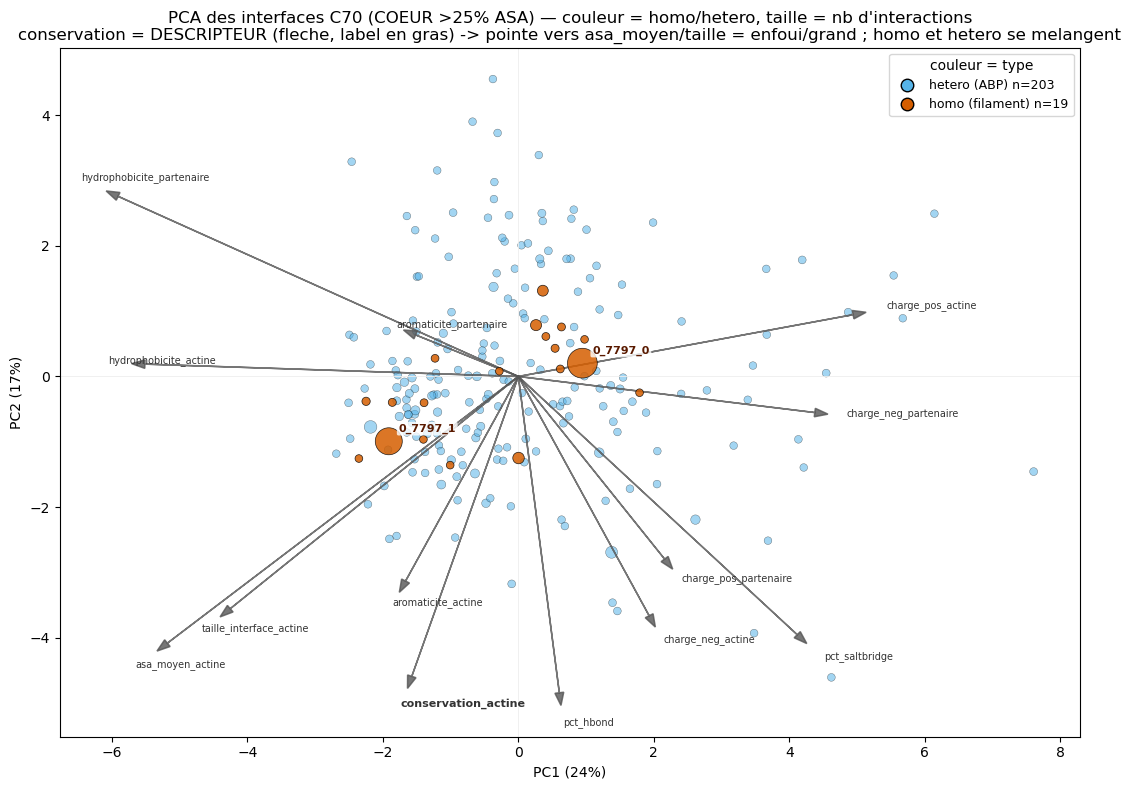

In [8]:
# === PCA des interfaces au niveau cluster C70 (homo + hetero) ===
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path as _P
from scipy.spatial.distance import pdist, squareform
_R = _P('..') if _P('../data').exists() else _P('.')
_df3=pd.read_csv(_R/'data/filtered/details/3.interface_residues.csv')
_df3['pct']=pd.to_numeric(_df3['buried_ASA_percent'].astype(str).str.replace('%','',regex=False),errors='coerce')
_df3['a2']=pd.to_numeric(_df3['buried_ASA_Å²'].astype(str).str.replace('<0.1','0.05',regex=False),errors='coerce')
_df3['canon']=pd.to_numeric(_df3['residue_number_canon_mafft'],errors='coerce')
_df3=_df3[_df3.canon.notna()&_df3.pct.notna()].copy()
_di=pd.read_csv(_R/'data/filtered/details/1.interactions.csv')
_da=pd.read_csv(_R/'data/filtered/filtered_all_data.csv',low_memory=False)
_m=_di.merge(_da[['subunit_1','subunit_2','subunit_2_title','s2_actine','cluster_data_70']].drop_duplicates(),
             left_on=['chain_A_id','chain_B_id'],right_on=['subunit_1','subunit_2'],how='left').drop_duplicates('interaction_id')
_m=_m.dropna(subset=['cluster_data_70'])
_m['homo']=_m['s2_actine'].fillna(False).astype(bool)
_m['abp_title']=_m['subunit_2_title'].fillna('?').astype(str).str.replace(r'\s*\(.*?\)','',regex=True).str.strip().str[:22]
_clu2abp=_m[~_m['homo']].groupby('cluster_data_70')['abp_title'].agg(lambda x:x.value_counts().index[0])
_m['interface_area']=pd.to_numeric(_m['interface_area'].astype(str).str.replace('Å²','',regex=False).str.strip(),errors='coerce')
for _c in ['num_hbonds','num_salt_bridges','num_contacts']: _m[_c]=pd.to_numeric(_m[_c],errors='coerce')
_imap=_m.set_index('interaction_id'); _chA=_imap['chain_A_id'].str.lower(); _clu=_imap['cluster_data_70']
_d=_df3[_df3.interaction_id.isin(set(_m.interaction_id))].copy()
_d['_a']=_d.interaction_id.map(_chA); _d=_d[(_d.chain.str.lower()==_d._a)&(_d['pct']>25)].copy()   # cote actine COEUR >25% ASA
_d['clu']=_d.interaction_id.map(_clu); _d['canon']=_d.canon.astype(int)
_cdf=pd.read_csv(_R/'data/proteocast/conservation_vs_asa_per_position.csv'); _cons=dict(zip(_cdf['canon'].astype(int),_cdf['conservation']))
_clsmap=dict(zip(_cdf['canon'].astype(int),_cdf['residue_class']))   # canon -> sensitive/tolerant
_KD={'A':1.8,'R':-4.5,'N':-3.5,'D':-3.5,'C':2.5,'Q':-3.5,'E':-3.5,'G':-0.4,'H':-3.2,'I':4.5,'L':3.8,'K':-3.9,'M':1.9,'F':2.8,'P':-1.6,'S':-0.8,'T':-0.7,'W':-0.9,'Y':-1.3,'V':4.2}
def _md(s): mm=s.mode(); return mm.iloc[0] if len(mm) else None
_po=_d.groupby(['clu','canon']).agg(w=('pct','mean'),res=('residue_name',_md)).reset_index()
_po['kd']=_po['res'].map(lambda r:_KD.get(str(r),0.0)); _po['cons']=_po['canon'].map(lambda c:_cons.get(int(c),np.nan))
_po['ispos']=_po['res'].isin({'R','K'}).astype(float); _po['isneg']=_po['res'].isin({'D','E'}).astype(float); _po['isaro']=_po['res'].isin({'F','Y','W'}).astype(float)
def _wmi(g,c):
    w=g['w'].values; x=g[c].values; mk=~np.isnan(x)
    return (w[mk]*x[mk]).sum()/w[mk].sum() if w[mk].sum()>0 else np.nan
Fi=_po.groupby('clu').apply(lambda g:pd.Series({'conservation_actine':_wmi(g,'cons'),'hydrophobicite_actine':_wmi(g,'kd'),
    'charge_pos_actine':_wmi(g,'ispos'),'charge_neg_actine':_wmi(g,'isneg'),'aromaticite_actine':_wmi(g,'isaro'),'asa_moyen_actine':_wmi(g,'w')}))
Fi['n_residus']=_d.groupby('interaction_id').size().groupby(_clu).mean()
_ag=_m.groupby('cluster_data_70').agg(hb=('num_hbonds','sum'),sb=('num_salt_bridges','sum'),
    ct=('num_contacts','sum'),n=('interaction_id','nunique'),homo=('homo','mean'))
Fi['taille_interface_actine']=_d.groupby('interaction_id')['a2'].sum().groupby(_clu).mean()
Fi=Fi.join(_ag[['homo']])
_cc=pd.read_csv(_R/'data/filtered/details/4.inter-residue_contacts.csv'); _CHG={'R':1,'K':1,'D':-1,'E':-1}
_cc=_cc[_cc.interaction_id.isin(set(_m.interaction_id))].copy(); _cc['_clu']=_cc.interaction_id.map(_clu)
_cc['charge_compl']=-(_cc['residue_A_name'].map(lambda r:_CHG.get(str(r),0))*_cc['residue_B_name'].map(lambda r:_CHG.get(str(r),0)))
Fi['charge_compl']=_cc.groupby('_clu')['charge_compl'].mean()
Fi['pct_hbond']=100*_ag['hb']/_ag['ct']; Fi['pct_saltbridge']=100*_ag['sb']/_ag['ct']
# --- descripteurs cote PARTENAIRE (chaine B = S2 ; actine pour homo, ABP pour hetero) ---
_chB=_imap['chain_B_id'].str.lower()
_db=_df3[_df3.interaction_id.isin(set(_m.interaction_id))].copy()
_db['_b']=_db.interaction_id.map(_chB); _db=_db[(_db.chain.str.lower()==_db._b)&(_db['pct']>25)].copy()  # partenaire COEUR >25%
_db['clu']=_db.interaction_id.map(_clu)
_db['kd']=_db['residue_name'].map(lambda r:_KD.get(str(r),0.0))
_db['ispos']=_db['residue_name'].isin({'R','K'}).astype(float)
_db['isneg']=_db['residue_name'].isin({'D','E'}).astype(float)
_db['isaro']=_db['residue_name'].isin({'F','Y','W'}).astype(float)
def _wmb(g,col):
    w=g['pct'].values; x=g[col].values; mk=~np.isnan(x)
    return (w[mk]*x[mk]).sum()/w[mk].sum() if w[mk].sum()>0 else np.nan
Fb=_db.groupby('clu').apply(lambda g:pd.Series({'hydrophobicite_partenaire':_wmb(g,'kd'),
    'charge_pos_partenaire':_wmb(g,'ispos'),'charge_neg_partenaire':_wmb(g,'isneg'),'aromaticite_partenaire':_wmb(g,'isaro'),'asa_moyen_partenaire':g['pct'].mean()}))
Fi=Fi.join(Fb)
_featI=['conservation_actine','hydrophobicite_actine','charge_pos_actine','charge_neg_actine','aromaticite_actine','taille_interface_actine','asa_moyen_actine','pct_hbond','pct_saltbridge','hydrophobicite_partenaire','charge_pos_partenaire','charge_neg_partenaire','aromaticite_partenaire']  # conservation = DESCRIPTEUR (fleche) ; couleur = homo/hetero -> non circulaire
Fi=Fi.dropna(subset=_featI); _homo=Fi['homo']>0.5
print(f"{len(Fi)} clusters d'interface C70 ({int(_homo.sum())} homo / {int((~_homo).sum())} hetero)")

Xi=Fi[_featI].values.astype(float); Xzi=(Xi-Xi.mean(0))/(Xi.std(0)+1e-9)
Xci=Xzi-Xzi.mean(0); Ui,Si,Vti=np.linalg.svd(Xci,full_matrices=False); pcsi=Ui[:,:2]*Si[:2]; evi=(Si**2)/(Si**2).sum()*100
print(f"Variance PC1+PC2 = {evi[0]:.0f}% + {evi[1]:.0f}% = {evi[0]+evi[1]:.0f}%")
_Di=squareform(pdist(Xzi)); _lab=_homo.values.astype(int)
def _sili(D,lab):
    n=len(lab);s=np.zeros(n)
    for i in range(n):
        sm=(lab==lab[i]).copy();sm[i]=False
        a=D[i,sm].mean() if sm.any() else 0; b=min((D[i,lab==c].mean() for c in set(lab) if c!=lab[i]),default=0)
        s[i]=0 if max(a,b)==0 else (b-a)/max(a,b)
    return s.mean()
print(f"Silhouette separation homo vs hetero = {_sili(_Di,_lab):.3f}  (~0 -> interfaces homo non distinctes des hetero)")

_corI=np.array([[np.corrcoef(Xzi[:,j],pcsi[:,k])[0,1] for k in range(2)] for j in range(len(_featI))])
from matplotlib.lines import Line2D
_npc=_ag['n'].reindex(Fi.index).values.astype(float)            # nb d'interactions
_sz=30+(_npc/np.nanmax(_npc))*430                                # taille proportionnelle
_he=~_homo.values; _ho=_homo.values
_chet='#56B4E9'; _chomo='#D55E00'                                # couleur = type (Okabe-Ito)

fig,ax=plt.subplots(figsize=(11,8))
ax.scatter(pcsi[_he,0],pcsi[_he,1],c=_chet,s=_sz[_he],marker='o',edgecolor='k',lw=.3,alpha=.55,zorder=2)   # hetero
ax.scatter(pcsi[_ho,0],pcsi[_ho,1],c=_chomo,s=_sz[_ho],marker='o',edgecolor='k',lw=.5,alpha=.85,zorder=4)  # homo (meme marqueur)
_fI=0.8*np.abs(pcsi).max()/np.abs(_corI).max()
for j,nm in enumerate(_featI):
    _isc = (nm=='conservation_actine')                          # fleches uniformes, gris fonce
    ax.arrow(0,0,_corI[j,0]*_fI,_corI[j,1]*_fI,color='#555',
             head_width=.13,length_includes_head=True,lw=1.1,alpha=.8,zorder=3)
    ax.annotate(nm,(_corI[j,0]*_fI*1.06,_corI[j,1]*_fI*1.06),fontsize=(8 if _isc else 7),
                color='#333',fontweight=('bold' if _isc else 'normal'),zorder=7)
ax.legend(handles=[Line2D([0],[0],marker='o',ls='',mfc=_chet,mec='k',ms=9,label=f'hetero (ABP) n={int(_he.sum())}'),
                   Line2D([0],[0],marker='o',ls='',mfc=_chomo,mec='k',ms=9,label=f'homo (filament) n={int(_ho.sum())}')],
          loc='best',fontsize=9,title='couleur = type')
ax.axhline(0,color='#eee',lw=.6); ax.axvline(0,color='#eee',lw=.6)
ax.set_xlabel(f'PC1 ({evi[0]:.0f}%)'); ax.set_ylabel(f'PC2 ({evi[1]:.0f}%)')
ax.set_title("PCA des interfaces C70 (COEUR >25% ASA) — couleur = homo/hetero, taille = nb d'interactions\n"
             "conservation = DESCRIPTEUR (fleche, label en gras) -> pointe vers asa_moyen/taille = enfoui/grand ; homo et hetero se melangent")

# --- noms selectifs : 2 plus grosses interfaces filament + 1 label par ABP excentre ---
_dist2=np.hypot(pcsi[:,0],pcsi[:,1]); _idx2=list(Fi.index)
for i in np.where(_ho)[0][np.argsort(-_npc[np.where(_ho)[0]])][:2]:
    ax.annotate(f'{_idx2[i]}',(pcsi[i,0],pcsi[i,1]),fontsize=8,fontweight='bold',color='#5a1a00',
                xytext=(7,7),textcoords='offset points',zorder=9,
                bbox=dict(boxstyle='round,pad=.15',fc='white',ec='none',alpha=.8))
# (noms de proteines ABP retires pour l'instant)
plt.tight_layout(); plt.show()


### PCA cluster binding-site — zones de liaison de l'actine

Un point = un **cluster de binding-site** (`s1_binding_site_cluster_data_70`, ex. 6685_0) = une **zone de l'actine** pouvant être liée par plusieurs ABP. Complète la PCA C70 (qui était par interface).

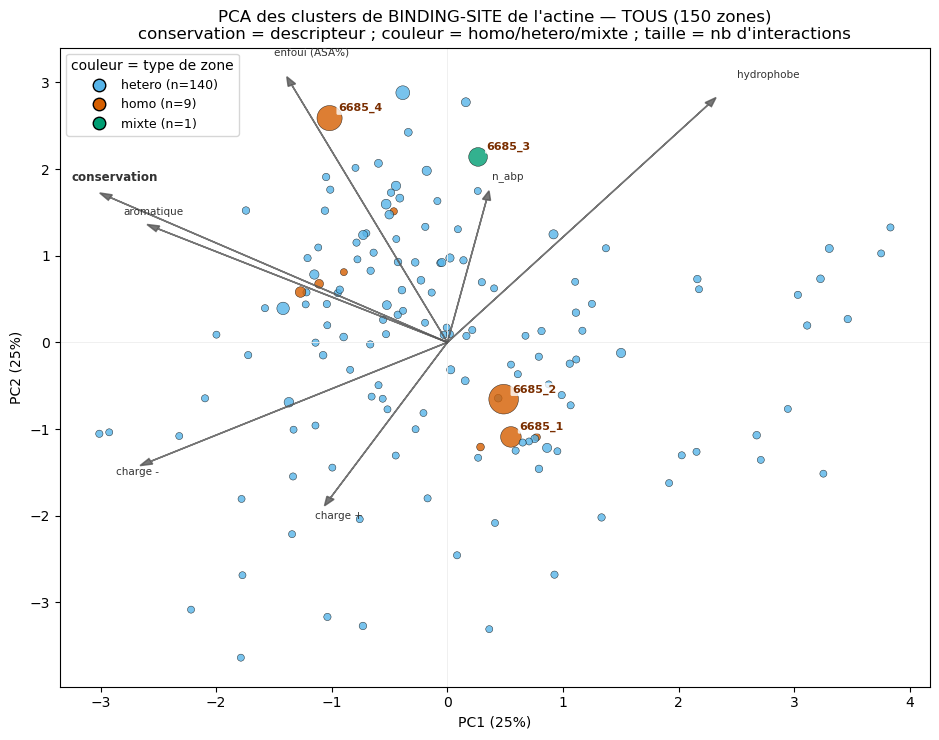

150 zones | classes: {'hetero': 140, 'homo': 9, 'mixte': 1} | var PC1+PC2=50%


In [9]:
# === PCA des clusters de BINDING-SITE de l'actine — TOUS les clusters ===
# Un point = une ZONE de liaison (s1_binding_site_cluster_data_70). Conservation = DESCRIPTEUR (fleche) ;
# couleur = homo (filament) / hetero (ABP) / mixte (les deux). Taille = nb d'interactions.
from pathlib import Path as _Pb
_Rb=_Pb('..') if (_Pb('..')/'data').exists() else _Pb('.')
_KDb={'A':1.8,'R':-4.5,'N':-3.5,'D':-3.5,'C':2.5,'Q':-3.5,'E':-3.5,'G':-0.4,'H':-3.2,'I':4.5,'L':3.8,'K':-3.9,'M':1.9,'F':2.8,'P':-1.6,'S':-0.8,'T':-0.7,'W':-0.9,'Y':-1.3,'V':4.2}
_HYD=set('AVLIMFWC')   # residus hydrophobes
_dab=pd.read_csv(_Rb/'data/filtered/filtered_all_data.csv',low_memory=False)
_dib=pd.read_csv(_Rb/'data/filtered/details/1.interactions.csv')
_f3b=pd.read_csv(_Rb/'data/filtered/details/3.interface_residues.csv')
_cvb=pd.read_csv(_Rb/'data/proteocast/conservation_vs_asa_per_position.csv').set_index('canon')['conservation']
_mb=_dib.merge(_dab[['subunit_1','subunit_2','s2_actine','s1_binding_site_cluster_data_70','s2_sequence_cluster_70']].drop_duplicates(),
               left_on=['chain_A_id','chain_B_id'],right_on=['subunit_1','subunit_2'],how='left')
_mb['s2_actine']=_mb['s2_actine'].fillna(False).astype(bool)
_mb=_mb.dropna(subset=['s1_binding_site_cluster_data_70'])
# classe : homo (que filament) / hetero (que ABP) / mixte (les deux)
_fh=_mb.groupby('s1_binding_site_cluster_data_70')['s2_actine'].mean()
_zcls=_fh.map(lambda f:'homo' if f==1 else ('hetero' if f==0 else 'mixte'))
# nb d'ABP distincts (cluster sequence 70%) par zone, cote hetero
_nabp=_mb[~_mb.s2_actine].groupby('s1_binding_site_cluster_data_70')['s2_sequence_cluster_70'].nunique()
_iid2bs=_mb.set_index('interaction_id')['s1_binding_site_cluster_data_70']
_iid2act=_mb.set_index('interaction_id')['chain_A_id'].str.lower()
_f3b['pct']=pd.to_numeric(_f3b['buried_ASA_percent'].astype(str).str.replace('%','',regex=False),errors='coerce')
_f3b['canon']=pd.to_numeric(_f3b['residue_number_canon_mafft'],errors='coerce')
_f3b['aa']=_f3b['residue_name'].astype(str).str.upper().str.strip()
_f3b['bs']=_f3b.interaction_id.map(_iid2bs); _f3b['act']=_f3b.interaction_id.map(_iid2act)
_aB=_f3b[(_f3b.chain.str.lower()==_f3b.act)&_f3b.bs.notna()&(_f3b.aa.str.len()==1)].copy()
_aB['kd']=_aB.aa.map(_KDb); _aB['hyd']=_aB.aa.isin(_HYD); _aB['pos']=_aB.aa.isin(list('KR')); _aB['neg']=_aB.aa.isin(list('DE'))
_aB['aro']=_aB.aa.isin(list('FWY')); _aB['cons']=_aB.canon.map(_cvb)
_gB=_aB.groupby('bs')
_descB=pd.DataFrame({'conservation':_gB['cons'].mean(),'hydrophobe':_gB['hyd'].mean(),'charge +':_gB['pos'].mean(),
   'charge -':_gB['neg'].mean(),'aromatique':_gB['aro'].mean(),'enfoui (ASA%)':_gB['pct'].mean(),
   'n_intx':_gB['interaction_id'].nunique()})
_descB['n_abp']=_nabp.reindex(_descB.index).fillna(0)
_descB['classe']=_zcls.reindex(_descB.index)
_bf=['conservation','hydrophobe','charge +','charge -','aromatique','enfoui (ASA%)','n_abp']
_descB=_descB.dropna(subset=_bf)
_XB=_descB[_bf].values; _XBz=(_XB-_XB.mean(0))/(_XB.std(0)+1e-9)
_UB,_SB,_VtB=np.linalg.svd(_XBz-_XBz.mean(0),full_matrices=False); _pcB=_UB[:,:2]*_SB[:2]; _evB=(_SB**2)/np.sum(_SB**2)
_corB=np.array([[np.corrcoef(_XBz[:,j],_pcB[:,k])[0,1] for k in range(2)] for j in range(len(_bf))])

from matplotlib.lines import Line2D
_cc={'hetero':'#56B4E9','homo':'#D55E00','mixte':'#009E73'}
_cols=_descB['classe'].map(_cc).values
_sz=25+(_descB['n_intx'].values/_descB['n_intx'].max())*430
fig,ax=plt.subplots(figsize=(9.5,7.5))
ax.scatter(_pcB[:,0],_pcB[:,1],c=_cols,s=_sz,edgecolor='k',lw=.35,alpha=.8)
_fb=0.8*np.abs(_pcB).max()/np.abs(_corB).max()
for j,nm in enumerate(_bf):
    _isc=(nm=='conservation')
    ax.arrow(0,0,_corB[j,0]*_fb,_corB[j,1]*_fb,color='#555',head_width=.07,lw=1.1,length_includes_head=True,alpha=.8,zorder=3)
    ax.annotate(nm,(_corB[j,0]*_fb*1.08,_corB[j,1]*_fb*1.08),fontsize=(8.5 if _isc else 7.5),
                color='#333',fontweight=('bold' if _isc else 'normal'),zorder=6)
# noms des 4 clusters principaux (interfaces filament : 6685_1..4)
_idxB=list(_descB.index)
for b in ['6685_1','6685_2','6685_3','6685_4']:
    if b in _idxB:
        i=_idxB.index(b)
        ax.annotate(b,(_pcB[i,0],_pcB[i,1]),fontsize=8,fontweight='bold',color='#7a2e00',
                    xytext=(6,5),textcoords='offset points',zorder=7,
                    bbox=dict(boxstyle='round,pad=.13',fc='white',ec='none',alpha=.8))
ax.legend(handles=[Line2D([0],[0],marker='o',ls='',mfc=_cc[g],mec='k',ms=9,
                          label=f'{g} (n={int((_descB.classe==g).sum())})') for g in ['hetero','homo','mixte'] if (_descB.classe==g).any()],
          loc='best',fontsize=9,title='couleur = type de zone')
ax.axhline(0,color='#eee',lw=.6); ax.axvline(0,color='#eee',lw=.6)
ax.set_xlabel(f'PC1 ({_evB[0]*100:.0f}%)'); ax.set_ylabel(f'PC2 ({_evB[1]*100:.0f}%)')
ax.set_title(f"PCA des clusters de BINDING-SITE de l'actine — TOUS ({len(_descB)} zones)\n"
             "conservation = descripteur ; couleur = homo/hetero/mixte ; taille = nb d'interactions")
plt.tight_layout(); plt.show()
print(f"{len(_descB)} zones | classes: {_descB['classe'].value_counts().to_dict()} | var PC1+PC2={(_evB[0]+_evB[1])*100:.0f}%")


### Variante — binding-site, COEUR seulement (résidus > 25 % ASA)

Même PCA mais les descripteurs de chaque zone ne sont calculés que sur les **résidus réellement enfouis (> 25 % ASA)** — on retire les contacts superficiels (effleurements).

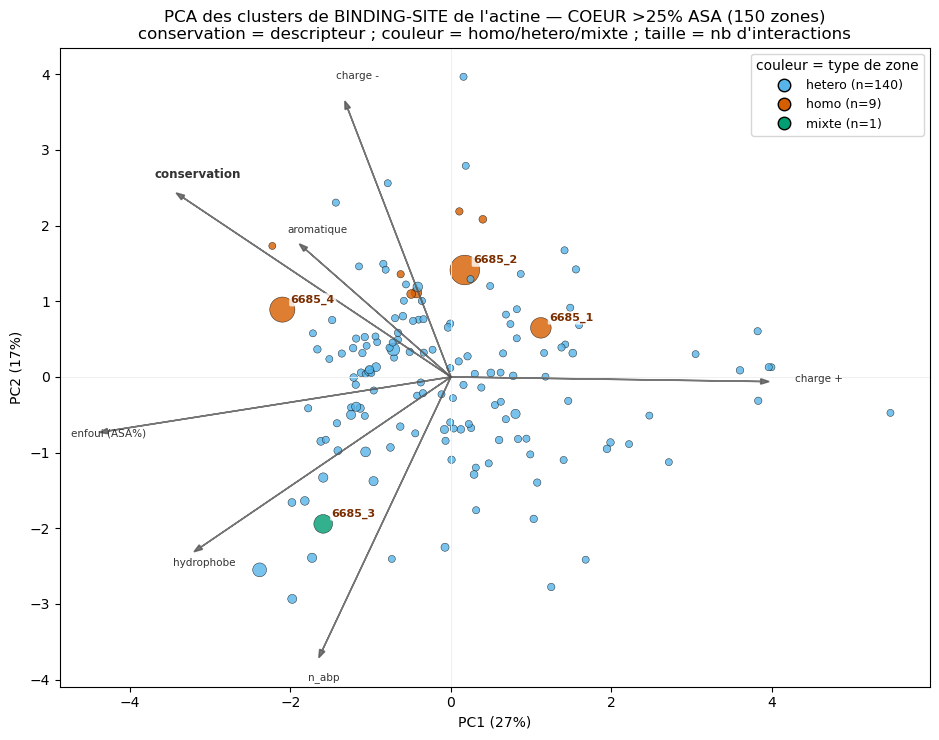

150 zones | classes: {'hetero': 140, 'homo': 9, 'mixte': 1} | var PC1+PC2=44%


In [10]:
# === PCA des clusters de BINDING-SITE de l'actine — COEUR (residus >25% ASA) ===
# Un point = une ZONE de liaison (s1_binding_site_cluster_data_70). Conservation = DESCRIPTEUR (fleche) ;
# couleur = homo (filament) / hetero (ABP) / mixte (les deux). Taille = nb d'interactions.
from pathlib import Path as _Pb
_Rb=_Pb('..') if (_Pb('..')/'data').exists() else _Pb('.')
_KDb={'A':1.8,'R':-4.5,'N':-3.5,'D':-3.5,'C':2.5,'Q':-3.5,'E':-3.5,'G':-0.4,'H':-3.2,'I':4.5,'L':3.8,'K':-3.9,'M':1.9,'F':2.8,'P':-1.6,'S':-0.8,'T':-0.7,'W':-0.9,'Y':-1.3,'V':4.2}
_HYD=set('AVLIMFWC')   # residus hydrophobes
_dabcr=pd.read_csv(_Rb/'data/filtered/filtered_all_data.csv',low_memory=False)
_dibcr=pd.read_csv(_Rb/'data/filtered/details/1.interactions.csv')
_f3bcr=pd.read_csv(_Rb/'data/filtered/details/3.interface_residues.csv')
_cvbcr=pd.read_csv(_Rb/'data/proteocast/conservation_vs_asa_per_position.csv').set_index('canon')['conservation']
_mbcr=_dibcr.merge(_dabcr[['subunit_1','subunit_2','s2_actine','s1_binding_site_cluster_data_70','s2_sequence_cluster_70']].drop_duplicates(),
               left_on=['chain_A_id','chain_B_id'],right_on=['subunit_1','subunit_2'],how='left')
_mbcr['s2_actine']=_mbcr['s2_actine'].fillna(False).astype(bool)
_mbcr=_mbcr.dropna(subset=['s1_binding_site_cluster_data_70'])
# classe : homo (que filament) / hetero (que ABP) / mixte (les deux)
_fhcr=_mbcr.groupby('s1_binding_site_cluster_data_70')['s2_actine'].mean()
_zclscr=_fhcr.map(lambda f:'homo' if f==1 else ('hetero' if f==0 else 'mixte'))
# nb d'ABP distincts (cluster sequence 70%) par zone, cote hetero
_nabpcr=_mbcr[~_mbcr.s2_actine].groupby('s1_binding_site_cluster_data_70')['s2_sequence_cluster_70'].nunique()
_iid2bscr=_mbcr.set_index('interaction_id')['s1_binding_site_cluster_data_70']
_iid2actcr=_mbcr.set_index('interaction_id')['chain_A_id'].str.lower()
_f3bcr['pct']=pd.to_numeric(_f3bcr['buried_ASA_percent'].astype(str).str.replace('%','',regex=False),errors='coerce')
_f3bcr['canon']=pd.to_numeric(_f3bcr['residue_number_canon_mafft'],errors='coerce')
_f3bcr['aa']=_f3bcr['residue_name'].astype(str).str.upper().str.strip()
_f3bcr['bs']=_f3bcr.interaction_id.map(_iid2bscr); _f3bcr['act']=_f3bcr.interaction_id.map(_iid2actcr)
_aBcr=_f3bcr[(_f3bcr.chain.str.lower()==_f3bcr.act)&_f3bcr.bs.notna()&(_f3bcr.aa.str.len()==1)&(_f3bcr['pct']>25)].copy()  # COEUR : residus enfouis >25% ASA seulement
_aBcr['kd']=_aBcr.aa.map(_KDb); _aBcr['hyd']=_aBcr.aa.isin(_HYD); _aBcr['pos']=_aBcr.aa.isin(list('KR')); _aBcr['neg']=_aBcr.aa.isin(list('DE'))
_aBcr['aro']=_aBcr.aa.isin(list('FWY')); _aBcr['cons']=_aBcr.canon.map(_cvbcr)
_gBcr=_aBcr.groupby('bs')
_descBcr=pd.DataFrame({'conservation':_gBcr['cons'].mean(),'hydrophobe':_gBcr['hyd'].mean(),'charge +':_gBcr['pos'].mean(),
   'charge -':_gBcr['neg'].mean(),'aromatique':_gBcr['aro'].mean(),'enfoui (ASA%)':_gBcr['pct'].mean(),
   'n_intx':_gBcr['interaction_id'].nunique()})
_descBcr['n_abp']=_nabpcr.reindex(_descBcr.index).fillna(0)
_descBcr['classe']=_zclscr.reindex(_descBcr.index)
_bfcr=['conservation','hydrophobe','charge +','charge -','aromatique','enfoui (ASA%)','n_abp']
_descBcr=_descBcr.dropna(subset=_bfcr)
_XBcr=_descBcr[_bfcr].values; _XBcrz=(_XBcr-_XBcr.mean(0))/(_XBcr.std(0)+1e-9)
_UBcr,_SBcr,_VtBcr=np.linalg.svd(_XBcrz-_XBcrz.mean(0),full_matrices=False); _pcBcr=_UBcr[:,:2]*_SBcr[:2]; _evBcr=(_SBcr**2)/np.sum(_SBcr**2)
_corBcr=np.array([[np.corrcoef(_XBcrz[:,j],_pcBcr[:,k])[0,1] for k in range(2)] for j in range(len(_bfcr))])

from matplotlib.lines import Line2D
_cccr={'hetero':'#56B4E9','homo':'#D55E00','mixte':'#009E73'}
_colscr=_descBcr['classe'].map(_cccr).values
_szcr=25+(_descBcr['n_intx'].values/_descBcr['n_intx'].max())*430
fig,ax=plt.subplots(figsize=(9.5,7.5))
ax.scatter(_pcBcr[:,0],_pcBcr[:,1],c=_colscr,s=_szcr,edgecolor='k',lw=.35,alpha=.8)
_fbcr=0.8*np.abs(_pcBcr).max()/np.abs(_corBcr).max()
for j,nm in enumerate(_bfcr):
    _isc=(nm=='conservation')
    ax.arrow(0,0,_corBcr[j,0]*_fbcr,_corBcr[j,1]*_fbcr,color='#555',head_width=.07,lw=1.1,length_includes_head=True,alpha=.8,zorder=3)
    ax.annotate(nm,(_corBcr[j,0]*_fbcr*1.08,_corBcr[j,1]*_fbcr*1.08),fontsize=(8.5 if _isc else 7.5),
                color='#333',fontweight=('bold' if _isc else 'normal'),zorder=6)
# noms des 4 clusters principaux (interfaces filament : 6685_1..4)
_idxBcr=list(_descBcr.index)
for b in ['6685_1','6685_2','6685_3','6685_4']:
    if b in _idxBcr:
        i=_idxBcr.index(b)
        ax.annotate(b,(_pcBcr[i,0],_pcBcr[i,1]),fontsize=8,fontweight='bold',color='#7a2e00',
                    xytext=(6,5),textcoords='offset points',zorder=7,
                    bbox=dict(boxstyle='round,pad=.13',fc='white',ec='none',alpha=.8))
ax.legend(handles=[Line2D([0],[0],marker='o',ls='',mfc=_cccr[g],mec='k',ms=9,
                          label=f'{g} (n={int((_descBcr.classe==g).sum())})') for g in ['hetero','homo','mixte'] if (_descBcr.classe==g).any()],
          loc='best',fontsize=9,title='couleur = type de zone')
ax.axhline(0,color='#eee',lw=.6); ax.axvline(0,color='#eee',lw=.6)
ax.set_xlabel(f'PC1 ({_evBcr[0]*100:.0f}%)'); ax.set_ylabel(f'PC2 ({_evBcr[1]*100:.0f}%)')
ax.set_title(f"PCA des clusters de BINDING-SITE de l'actine — COEUR >25% ASA ({len(_descBcr)} zones)\n"
             "conservation = descripteur ; couleur = homo/hetero/mixte ; taille = nb d'interactions")
plt.tight_layout(); plt.show()
print(f"{len(_descBcr)} zones | classes: {_descBcr['classe'].value_counts().to_dict()} | var PC1+PC2={(_evBcr[0]+_evBcr[1])*100:.0f}%")


# C — PCA des contacts résidu-résidu

Un point = **un contact** résidu-résidu (124k). Couleur = **classe de conservation** de l'actine (sensitive/tolerant). La conservation est **retirée des descripteurs** → overlay non circulaire.

classes des contacts : {'sensitive': 91322, 'tolerant': 32831}
Variance PC1+PC2 = 17% + 12% = 29% (sans conservation, 11 descripteurs)


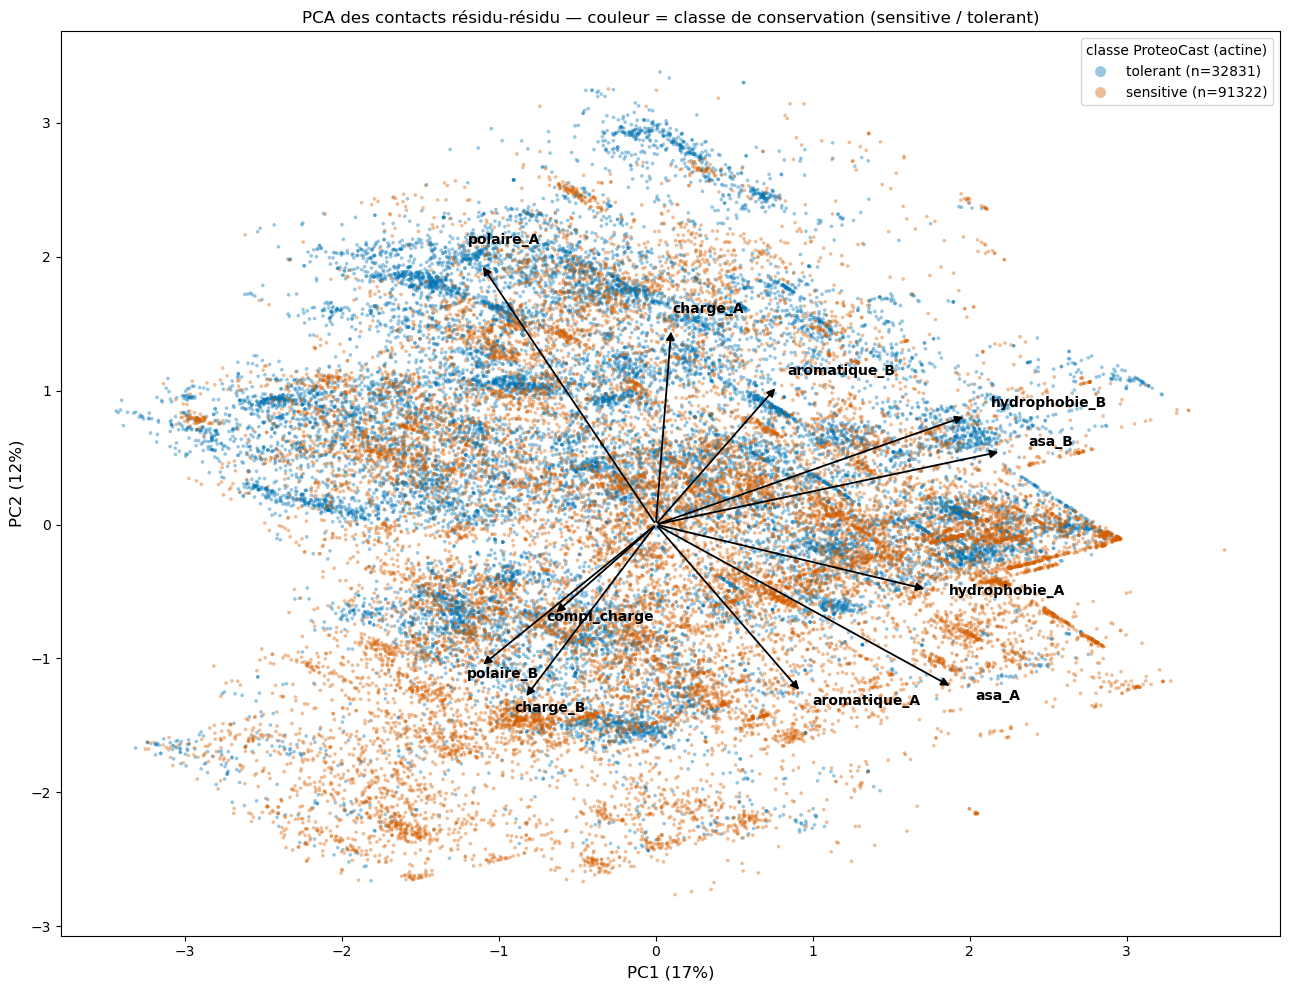

In [11]:
# === PCA des contacts residu-residu — couleur = classe (sensitive/tolerant) — AUTONOME ===
# === PCA des contacts residu-residu - descripteurs par cote A/B ===
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path as _P
_R=_P('..') if _P('../data').exists() else _P('.')
_c=pd.read_csv(_R/'data/filtered/details/4.inter-residue_contacts.csv',low_memory=False)
def _num(s): return pd.to_numeric(s.astype(str).str.replace('Å²','',regex=False).str.replace('%','',regex=False).str.strip(),errors='coerce')
_c['asa_A']=_num(_c['asa_pct_A']); _c['asa_B']=_num(_c['asa_pct_B'])   # %ASA (0-100)
_KD={'A':1.8,'R':-4.5,'N':-3.5,'D':-3.5,'C':2.5,'Q':-3.5,'E':-3.5,'G':-0.4,'H':-3.2,'I':4.5,'L':3.8,'K':-3.9,'M':1.9,'F':2.8,'P':-1.6,'S':-0.8,'T':-0.7,'W':-0.9,'Y':-1.3,'V':4.2}
_CHG={'R':1,'K':1,'D':-1,'E':-1}; _ARO={'F','Y','W'}; _POL={'S','T','N','Q','H','C'}
_a=_c['residue_A_name'].astype(str); _b=_c['residue_B_name'].astype(str)
_c['hydrophobie_A']=_a.map(lambda r:_KD.get(r,np.nan)); _c['hydrophobie_B']=_b.map(lambda r:_KD.get(r,np.nan))
_c['polaire_A']=_a.isin(_POL).astype(int); _c['polaire_B']=_b.isin(_POL).astype(int)
_qA=_a.map(lambda r:_CHG.get(r,0)); _qB=_b.map(lambda r:_CHG.get(r,0)); _c['compl_charge']=-(_qA*_qB)
_c['aromatique_A']=_a.isin(_ARO).astype(int); _c['aromatique_B']=_b.isin(_ARO).astype(int)
_c['charge_A']=_qA.values; _c['charge_B']=_qB.values             # charges nettes separees
# conservation cote actine
_pp=pd.read_csv(_R/'data/filtered/proteins_per_pdb.csv'); _ac=set(_pp[_pp.is_actin]['chain'].str.lower())
_cdf=pd.read_csv(_R/'data/proteocast/conservation_vs_asa_per_position.csv'); _cons=dict(zip(_cdf['canon'].astype(int),_cdf['conservation']))
_cnA=pd.to_numeric(_c['residue_A_canon_mafft'],errors='coerce'); _cnB=pd.to_numeric(_c['residue_B_canon_mafft'],errors='coerce')
_isA=_c['chain_A_id'].str.lower().isin(_ac).values; _isB=_c['chain_B_id'].str.lower().isin(_ac).values
_c['iface']=np.where(_isA&_isB,'actine-actine',np.where(_isA^_isB,'actine-ABP','autre'))  # type de contact homo/hetero
def _cv(cn,ia): return _cons.get(int(cn),np.nan) if (ia and pd.notna(cn)) else np.nan
_csA=np.array([_cv(cn,ia) for cn,ia in zip(_cnA,_isA)]); _csB=np.array([_cv(cn,ia) for cn,ia in zip(_cnB,_isB)])
_c['conservation_actine']=np.nanmean(np.vstack([_csA,_csB]),axis=0)
def _typ(t):
    if pd.isna(t): return 'vdW'
    if 'Salt' in t and 'H-bond' in t: return 'H-bond+sel'
    if 'Salt' in t: return 'pont salin'
    if 'H-bond' in t: return 'H-bond'
    return 'vdW'
_c['type']=_c['contact_type'].map(_typ)
_feat=['asa_A','asa_B','hydrophobie_A','hydrophobie_B','polaire_A','polaire_B','charge_A','charge_B','compl_charge','aromatique_A','aromatique_B','conservation_actine']
_c=_c.dropna(subset=[f for f in _feat if f!='conservation_actine']).reset_index(drop=True)  # retire contacts a residu inconnu (NaN) -> PCA stable

# === Variante : PCA des contacts SANS conservation, couleur = classe ProteoCast (actine) ===
# Cellule AUTONOME (le bloc data ci-dessous reconstruit _c, _feat, _cdf, _ac)
_clsmap=dict(zip(_cdf['canon'].astype(int),_cdf['residue_class']))   # canon -> sensitive / tolerant
_cnA=pd.to_numeric(_c['residue_A_canon_mafft'],errors='coerce'); _cnB=pd.to_numeric(_c['residue_B_canon_mafft'],errors='coerce')
_isA=_c['chain_A_id'].str.lower().isin(_ac).values; _isB=_c['chain_B_id'].str.lower().isin(_ac).values
_clA=_cnA.map(lambda x:_clsmap.get(int(x)) if pd.notna(x) else None)
_clB=_cnB.map(lambda x:_clsmap.get(int(x)) if pd.notna(x) else None)
_clsv=np.array(['inconnu']*len(_c),dtype=object)
_useB=_isB & _clB.notna().values; _clsv[_useB]=_clB[_useB].astype(str).values
_useA=_isA & _clA.notna().values; _clsv[_useA]=_clA[_useA].astype(str).values   # cote actine A prioritaire
import collections as _co; print('classes des contacts :', dict(_co.Counter(_clsv)))

# PCA sans le descripteur conservation_actine
_featc=[f for f in _feat if f!='conservation_actine']
_Xk=_c[_featc].values.astype(float); _Xkz=(_Xk-_Xk.mean(0))/(_Xk.std(0)+1e-9)
_Xkc=_Xkz-_Xkz.mean(0)
# PCA via diagonalisation de la covariance 11x11 (stable, evite l'echec SVD sur 124k lignes)
_cov=np.cov(_Xkc.T); _val,_vec=np.linalg.eigh(_cov); _o=_val.argsort()[::-1]; _val,_vec=_val[_o],_vec[:,_o]
_pcsk=_Xkc@_vec[:,:2]; _evk=_val/_val.sum()*100
print(f"Variance PC1+PC2 = {_evk[0]:.0f}% + {_evk[1]:.0f}% = {_evk[0]+_evk[1]:.0f}% (sans conservation, {len(_featc)} descripteurs)")
_cork=np.array([[np.corrcoef(_Xkz[:,j],_pcsk[:,k])[0,1] for k in range(2)] for j in range(len(_featc))])

_ccol={'sensitive':'#D55E00','tolerant':'#0072B2','inconnu':'#dddddd'}
np.random.seed(0); fig,ax=plt.subplots(figsize=(13,10))
for g in ['inconnu','tolerant','sensitive']:   # sensitive par-dessus
    sub=np.where(_clsv==g)[0]
    if len(sub)==0: continue
    if len(sub)>18000: sub=np.random.choice(sub,18000,replace=False)
    ax.scatter(_pcsk[sub,0],_pcsk[sub,1],s=7,alpha=.25 if g=='inconnu' else .4,color=_ccol[g],label=f'{g} (n={int((_clsv==g).sum())})',edgecolor='none')
_fk=0.6*np.abs(_pcsk).max()/np.abs(_cork).max()
for j,nm in enumerate(_featc):
    ax.annotate('',xy=(_cork[j,0]*_fk,_cork[j,1]*_fk),xytext=(0,0),arrowprops=dict(arrowstyle='-|>',color='k',lw=1.3,mutation_scale=12),zorder=5)
    ax.annotate(nm,(_cork[j,0]*_fk*1.08,_cork[j,1]*_fk*1.08),fontsize=10,fontweight='bold',zorder=6)
ax.set_xlabel(f'PC1 ({_evk[0]:.0f}%)',fontsize=12); ax.set_ylabel(f'PC2 ({_evk[1]:.0f}%)',fontsize=12)
ax.legend(markerscale=3,fontsize=10,loc='best',title='classe ProteoCast (actine)')
ax.set_title('PCA des contacts résidu-résidu — couleur = classe de conservation (sensitive / tolerant)',fontsize=12)
plt.tight_layout(); plt.show()

### Variante — contacts résidu-résidu, COEUR (les 2 résidus > 25 % ASA)

Même PCA mais on ne garde que les contacts où **les deux** résidus sont enfouis > 25 % ASA (vrais contacts de cœur).

classes des contacts : {'sensitive': 67323, 'tolerant': 19700}
Variance PC1+PC2 = 18% + 12% = 29% (sans conservation, 11 descripteurs)


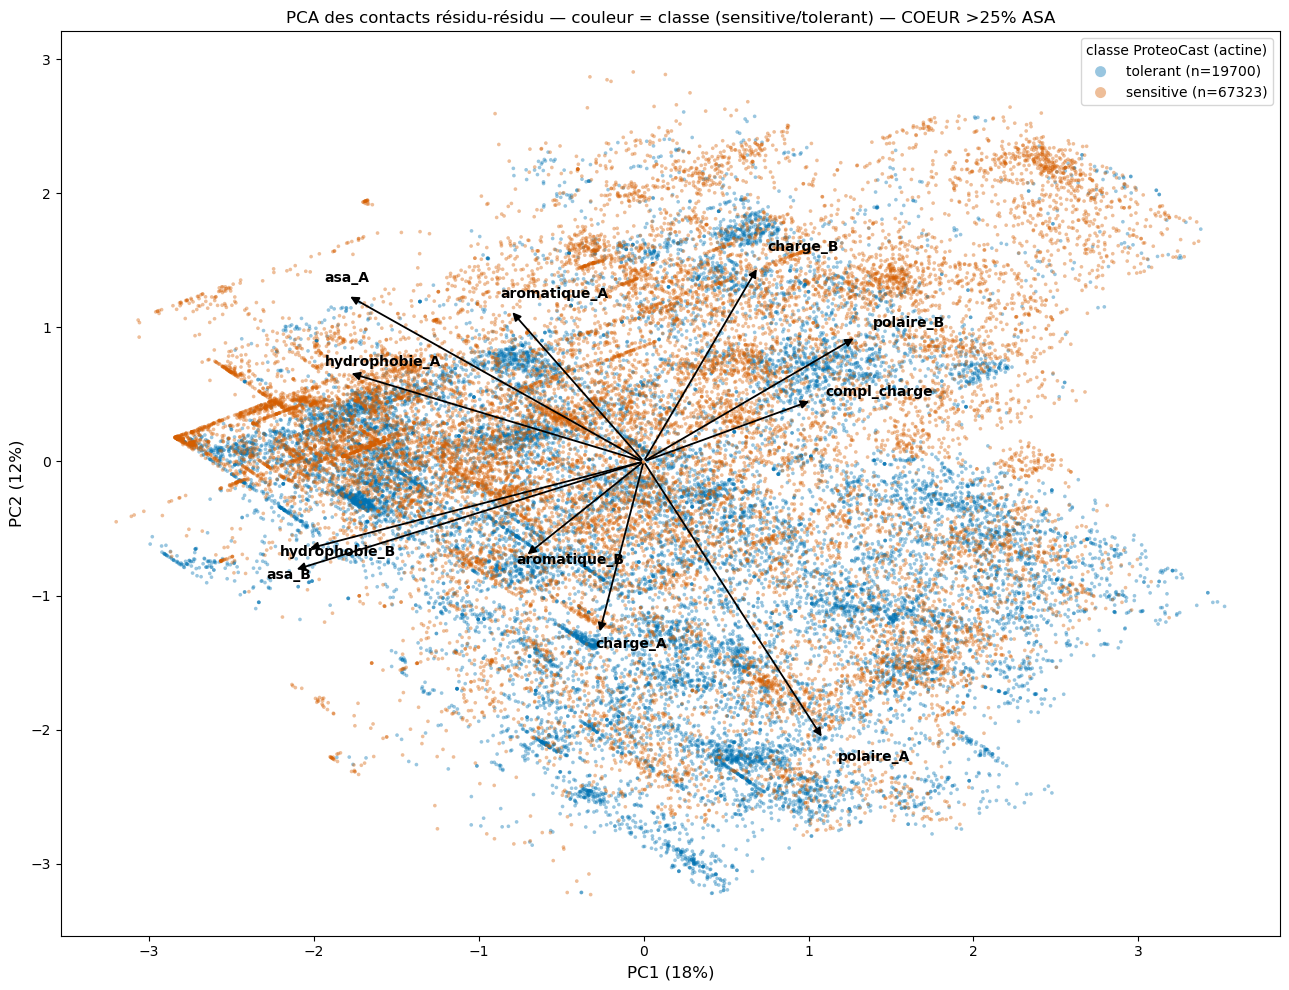

In [12]:
# === PCA des contacts residu-residu — couleur = classe (sensitive/tolerant) — AUTONOME ===
# === PCA des contacts residu-residu - descripteurs par cote A/B ===
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path as _P
_R=_P('..') if _P('../data').exists() else _P('.')
_c=pd.read_csv(_R/'data/filtered/details/4.inter-residue_contacts.csv',low_memory=False)
def _num(s): return pd.to_numeric(s.astype(str).str.replace('Å²','',regex=False).str.replace('%','',regex=False).str.strip(),errors='coerce')
_c['asa_A']=_num(_c['asa_pct_A']); _c['asa_B']=_num(_c['asa_pct_B'])   # %ASA (0-100)
_KD={'A':1.8,'R':-4.5,'N':-3.5,'D':-3.5,'C':2.5,'Q':-3.5,'E':-3.5,'G':-0.4,'H':-3.2,'I':4.5,'L':3.8,'K':-3.9,'M':1.9,'F':2.8,'P':-1.6,'S':-0.8,'T':-0.7,'W':-0.9,'Y':-1.3,'V':4.2}
_CHG={'R':1,'K':1,'D':-1,'E':-1}; _ARO={'F','Y','W'}; _POL={'S','T','N','Q','H','C'}
_a=_c['residue_A_name'].astype(str); _b=_c['residue_B_name'].astype(str)
_c['hydrophobie_A']=_a.map(lambda r:_KD.get(r,np.nan)); _c['hydrophobie_B']=_b.map(lambda r:_KD.get(r,np.nan))
_c['polaire_A']=_a.isin(_POL).astype(int); _c['polaire_B']=_b.isin(_POL).astype(int)
_qA=_a.map(lambda r:_CHG.get(r,0)); _qB=_b.map(lambda r:_CHG.get(r,0)); _c['compl_charge']=-(_qA*_qB)
_c['aromatique_A']=_a.isin(_ARO).astype(int); _c['aromatique_B']=_b.isin(_ARO).astype(int)
_c['charge_A']=_qA.values; _c['charge_B']=_qB.values             # charges nettes separees
# conservation cote actine
_pp=pd.read_csv(_R/'data/filtered/proteins_per_pdb.csv'); _ac=set(_pp[_pp.is_actin]['chain'].str.lower())
_cdf=pd.read_csv(_R/'data/proteocast/conservation_vs_asa_per_position.csv'); _cons=dict(zip(_cdf['canon'].astype(int),_cdf['conservation']))
_cnA=pd.to_numeric(_c['residue_A_canon_mafft'],errors='coerce'); _cnB=pd.to_numeric(_c['residue_B_canon_mafft'],errors='coerce')
_isA=_c['chain_A_id'].str.lower().isin(_ac).values; _isB=_c['chain_B_id'].str.lower().isin(_ac).values
_c['iface']=np.where(_isA&_isB,'actine-actine',np.where(_isA^_isB,'actine-ABP','autre'))  # type de contact homo/hetero
def _cv(cn,ia): return _cons.get(int(cn),np.nan) if (ia and pd.notna(cn)) else np.nan
_csA=np.array([_cv(cn,ia) for cn,ia in zip(_cnA,_isA)]); _csB=np.array([_cv(cn,ia) for cn,ia in zip(_cnB,_isB)])
_c['conservation_actine']=np.nanmean(np.vstack([_csA,_csB]),axis=0)
def _typ(t):
    if pd.isna(t): return 'vdW'
    if 'Salt' in t and 'H-bond' in t: return 'H-bond+sel'
    if 'Salt' in t: return 'pont salin'
    if 'H-bond' in t: return 'H-bond'
    return 'vdW'
_c['type']=_c['contact_type'].map(_typ)
_feat=['asa_A','asa_B','hydrophobie_A','hydrophobie_B','polaire_A','polaire_B','charge_A','charge_B','compl_charge','aromatique_A','aromatique_B','conservation_actine']
_c=_c.dropna(subset=[f for f in _feat if f!='conservation_actine']).reset_index(drop=True)
_c=_c[(_c['asa_A']>25)&(_c['asa_B']>25)].reset_index(drop=True)  # COEUR : les 2 residus enfouis >25% ASA  # retire contacts a residu inconnu (NaN) -> PCA stable

# === Variante : PCA des contacts SANS conservation, couleur = classe ProteoCast (actine) ===
# Cellule AUTONOME (le bloc data ci-dessous reconstruit _c, _feat, _cdf, _ac)
_clsmap=dict(zip(_cdf['canon'].astype(int),_cdf['residue_class']))   # canon -> sensitive / tolerant
_cnA=pd.to_numeric(_c['residue_A_canon_mafft'],errors='coerce'); _cnB=pd.to_numeric(_c['residue_B_canon_mafft'],errors='coerce')
_isA=_c['chain_A_id'].str.lower().isin(_ac).values; _isB=_c['chain_B_id'].str.lower().isin(_ac).values
_clA=_cnA.map(lambda x:_clsmap.get(int(x)) if pd.notna(x) else None)
_clB=_cnB.map(lambda x:_clsmap.get(int(x)) if pd.notna(x) else None)
_clsv=np.array(['inconnu']*len(_c),dtype=object)
_useB=_isB & _clB.notna().values; _clsv[_useB]=_clB[_useB].astype(str).values
_useA=_isA & _clA.notna().values; _clsv[_useA]=_clA[_useA].astype(str).values   # cote actine A prioritaire
import collections as _co; print('classes des contacts :', dict(_co.Counter(_clsv)))

# PCA sans le descripteur conservation_actine
_featc=[f for f in _feat if f!='conservation_actine']
_Xk=_c[_featc].values.astype(float); _Xkz=(_Xk-_Xk.mean(0))/(_Xk.std(0)+1e-9)
_Xkc=_Xkz-_Xkz.mean(0)
# PCA via diagonalisation de la covariance 11x11 (stable, evite l'echec SVD sur 124k lignes)
_cov=np.cov(_Xkc.T); _val,_vec=np.linalg.eigh(_cov); _o=_val.argsort()[::-1]; _val,_vec=_val[_o],_vec[:,_o]
_pcsk=_Xkc@_vec[:,:2]; _evk=_val/_val.sum()*100
print(f"Variance PC1+PC2 = {_evk[0]:.0f}% + {_evk[1]:.0f}% = {_evk[0]+_evk[1]:.0f}% (sans conservation, {len(_featc)} descripteurs)")
_cork=np.array([[np.corrcoef(_Xkz[:,j],_pcsk[:,k])[0,1] for k in range(2)] for j in range(len(_featc))])

_ccol={'sensitive':'#D55E00','tolerant':'#0072B2','inconnu':'#dddddd'}
np.random.seed(0); fig,ax=plt.subplots(figsize=(13,10))
for g in ['inconnu','tolerant','sensitive']:   # sensitive par-dessus
    sub=np.where(_clsv==g)[0]
    if len(sub)==0: continue
    if len(sub)>18000: sub=np.random.choice(sub,18000,replace=False)
    ax.scatter(_pcsk[sub,0],_pcsk[sub,1],s=7,alpha=.25 if g=='inconnu' else .4,color=_ccol[g],label=f'{g} (n={int((_clsv==g).sum())})',edgecolor='none')
_fk=0.6*np.abs(_pcsk).max()/np.abs(_cork).max()
for j,nm in enumerate(_featc):
    ax.annotate('',xy=(_cork[j,0]*_fk,_cork[j,1]*_fk),xytext=(0,0),arrowprops=dict(arrowstyle='-|>',color='k',lw=1.3,mutation_scale=12),zorder=5)
    ax.annotate(nm,(_cork[j,0]*_fk*1.08,_cork[j,1]*_fk*1.08),fontsize=10,fontweight='bold',zorder=6)
ax.set_xlabel(f'PC1 ({_evk[0]:.0f}%)',fontsize=12); ax.set_ylabel(f'PC2 ({_evk[1]:.0f}%)',fontsize=12)
ax.legend(markerscale=3,fontsize=10,loc='best',title='classe ProteoCast (actine)')
ax.set_title('PCA des contacts résidu-résidu — couleur = classe (sensitive/tolerant) — COEUR >25% ASA',fontsize=12)
plt.tight_layout(); plt.show()

# D — PCA des ABP

Un point = **un ABP**. Deux vues : (1) **empreinte** — ABP regroupés par leur *site* de liaison sur l'actine ; (2) **biophysique** — ABP décrits par la physico-chimie de leur interface.

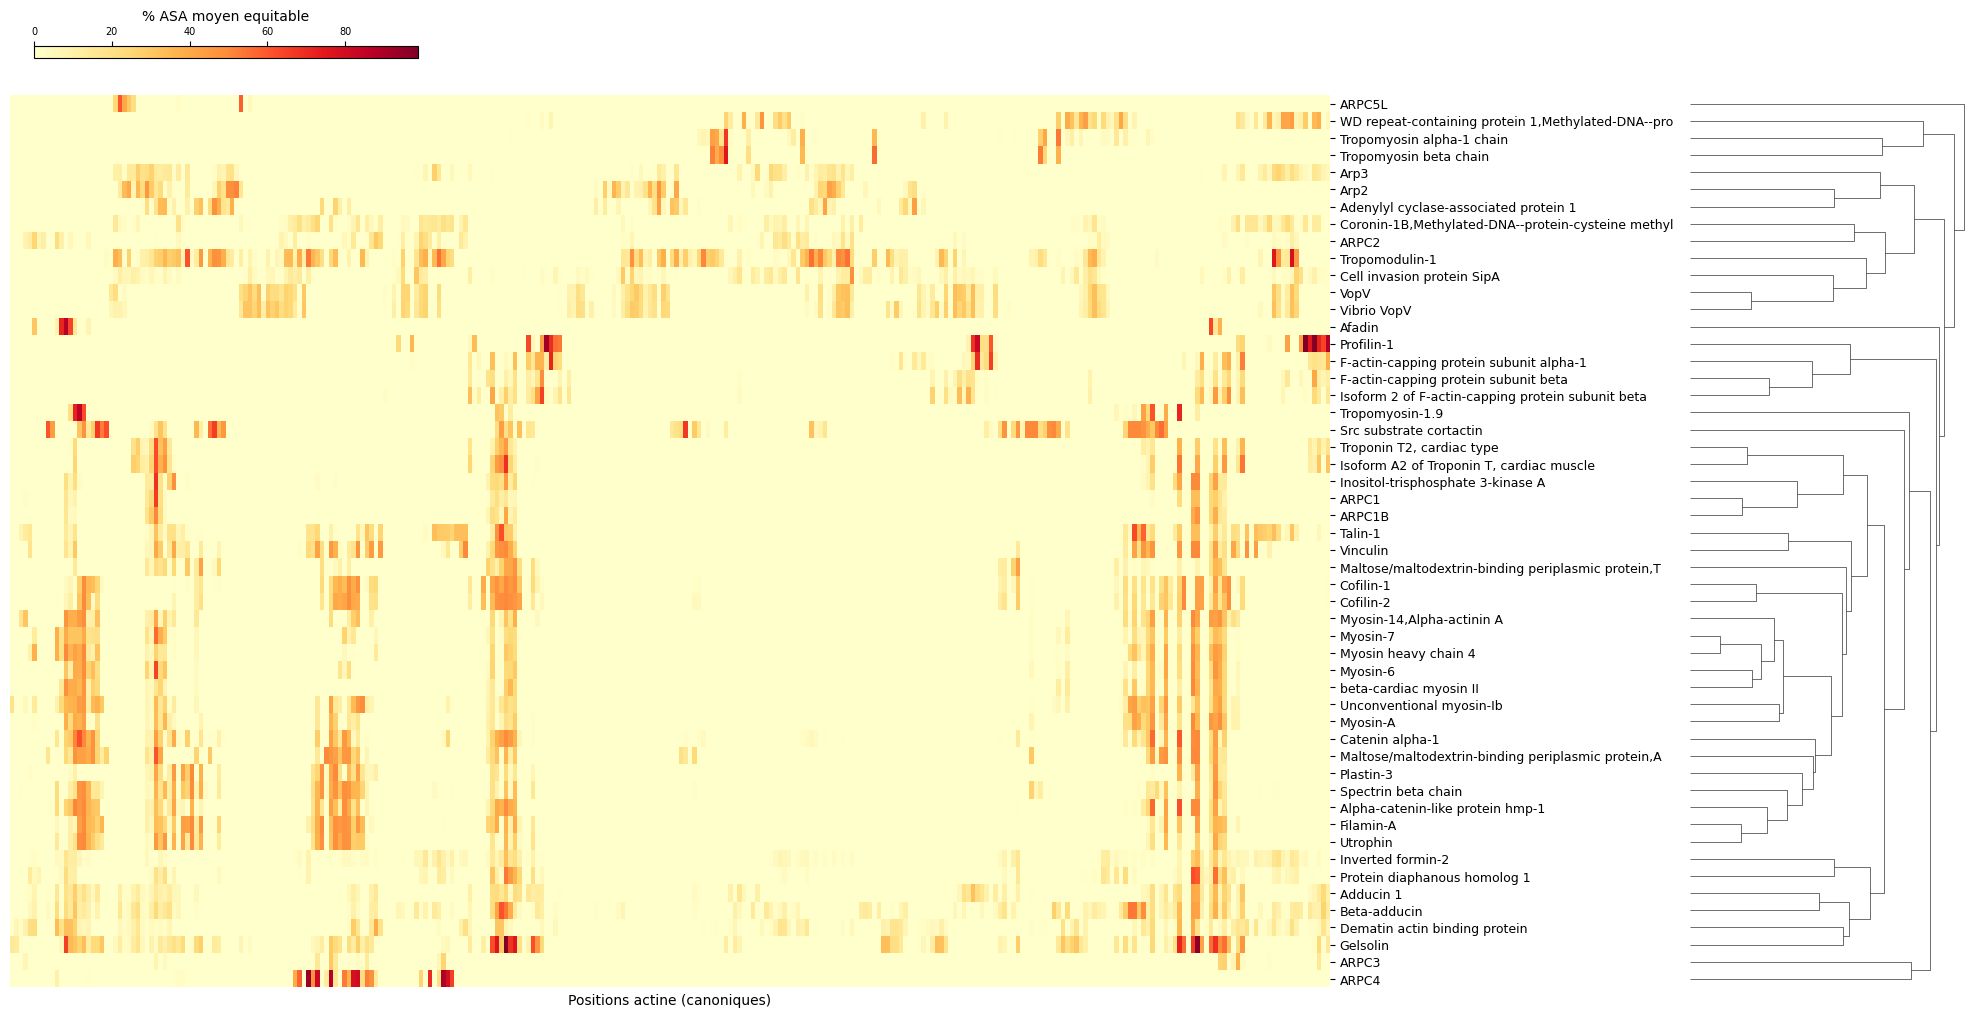

In [13]:
# Heatmap ABP x positions actine (= streamlit) + dendrogramme (pour Word)
import seaborn as sns, matplotlib as mpl
from scipy.cluster.hierarchy import leaves_list
from pathlib import Path as _P
_R = _P('..') if _P('../data').exists() else _P('.')
df3 = pd.read_csv(_R/'data/filtered/details/3.interface_residues.csv')
df3['buried_ASA_percent'] = pd.to_numeric(df3['buried_ASA_percent'].astype(str).str.replace('%','',regex=False), errors='coerce')
df3['canon'] = pd.to_numeric(df3['residue_number_canon_mafft'], errors='coerce')
df3 = df3[df3.canon.notna() & df3.buried_ASA_percent.notna()].copy()
di = pd.read_csv(_R/'data/filtered/details/1.interactions.csv')
da = pd.read_csv(_R/'data/filtered/filtered_all_data.csv', low_memory=False)
pp = pd.read_csv(_R/'data/filtered/proteins_per_pdb.csv')
actin_ch = set(pp[pp.is_actin]['chain'].str.lower())
homo = set(di[di['chain_B_id'].str.lower().isin(actin_ch)]['interaction_id'])
het = di[~di.interaction_id.isin(homo)].merge(
    da[['subunit_1','subunit_2','subunit_2_title','s2_actine','cluster_data_70']],
    left_on=['chain_A_id','chain_B_id'], right_on=['subunit_1','subunit_2'], how='left').drop_duplicates('interaction_id')
het = het[het['s2_actine'].fillna(False)==False].copy()
import re as _re
def _arp_name(n):
    if 'complex subunit 5-like' in n: return 'ARPC5L'
    mc = _re.search(r'complex subunit (\d+[A-Za-z]?)', n)
    if mc: return 'ARPC' + mc.group(1)
    if _re.match(r'Actin-related protein 3(\b|,|$)', n): return 'Arp3'
    if _re.match(r'Actin-related protein 2(\b|,|$)', n): return 'Arp2'
    return n
het['abp'] = het['subunit_2_title'].fillna('Unknown').str.replace(r'\s*\(.*?\)','',regex=True).str.strip().str[:50].map(_arp_name)
s1ch=het.set_index('interaction_id')['chain_A_id'].str.lower(); abpn=het.set_index('interaction_id')['abp']; c70n=het.set_index('interaction_id')['cluster_data_70']
d3 = df3[df3.interaction_id.isin(set(het.interaction_id))].copy()
d3['_s1c']=d3.interaction_id.map(s1ch); d3=d3[d3.chain.str.lower()==d3._s1c].copy()
d3['abp']=d3.interaction_id.map(abpn); d3['canon']=d3.canon.astype(int); d3['c70']=d3.interaction_id.map(c70n)
abp_freq=d3.groupby('abp')['interaction_id'].nunique().sort_values(ascending=False)
ac70n=d3.groupby(['abp','c70'])['interaction_id'].nunique()
ag=d3.groupby(['abp','c70','canon'])['buried_ASA_percent'].sum().reset_index(name='s')
ag['a70']=ag.apply(lambda r:r['s']/max(ac70n.get((r.abp,r.c70),1),1),axis=1)
nc70=d3.groupby('abp')['c70'].nunique()
eq=ag.groupby(['abp','canon'])['a70'].sum().reset_index(); eq['v']=eq['a70']/eq['abp'].map(nc70)
pivot=eq.pivot(index='abp',columns='canon',values='v').loc[abp_freq.index].fillna(0)   # noms seuls (pas de parentheses)

from scipy.cluster.hierarchy import linkage as _lkh
_Zbin=_lkh((pivot.values>0).astype(float), method='average', metric='jaccard')  # regroupement BINAIRE (presence/absence)
g=sns.clustermap(pivot, cmap='YlOrRd', figsize=(24,10.5), row_cluster=True, col_cluster=False, row_linkage=_Zbin,
                 dendrogram_ratio=(0.12,0.0), xticklabels=False, cbar_pos=None)  # couleurs=%ASA, lignes groupees en binaire
order=g.dendrogram_row.reordered_ind
g.ax_heatmap.yaxis.set_ticks_position('right'); g.ax_heatmap.yaxis.set_label_position('right')
g.ax_heatmap.set_yticks(np.arange(len(pivot))+0.5)
g.ax_heatmap.set_yticklabels([pivot.index[i] for i in order], fontsize=9, rotation=0)
g.ax_heatmap.set_ylabel('')
g.ax_heatmap.set_position([0.04, 0.06, 0.55, 0.85])   # heatmap a gauche
g.ax_row_dendrogram.set_position([0.74, 0.06, 0.12, 0.85]); g.ax_row_dendrogram.invert_xaxis()  # X=0.74 -> dendro colle aux noms (baisser X = plus proche)
g.ax_heatmap.set_xlabel('Positions actine (canoniques)')
# legende gradient : barre horizontale propre en haut a gauche
cax=g.fig.add_axes([0.05,0.945,0.16,0.012])
sm=mpl.cm.ScalarMappable(cmap='YlOrRd', norm=mpl.colors.Normalize(pivot.values.min(), pivot.values.max()))
g.fig.colorbar(sm, cax=cax, orientation='horizontal', label='% ASA moyen equitable')
cax.tick_params(labelsize=7); cax.xaxis.set_label_position('top'); cax.xaxis.set_ticks_position('top')
plt.show()

### Choix du nombre de clusters K — methode du coude\n\nAvant de fixer K=3 pour lempreinte ABP, on le justifie : inertie intra-cluster (coude) et silhouette en fonction de K, sur la meme donnee (profil %ASA, distance correlation).

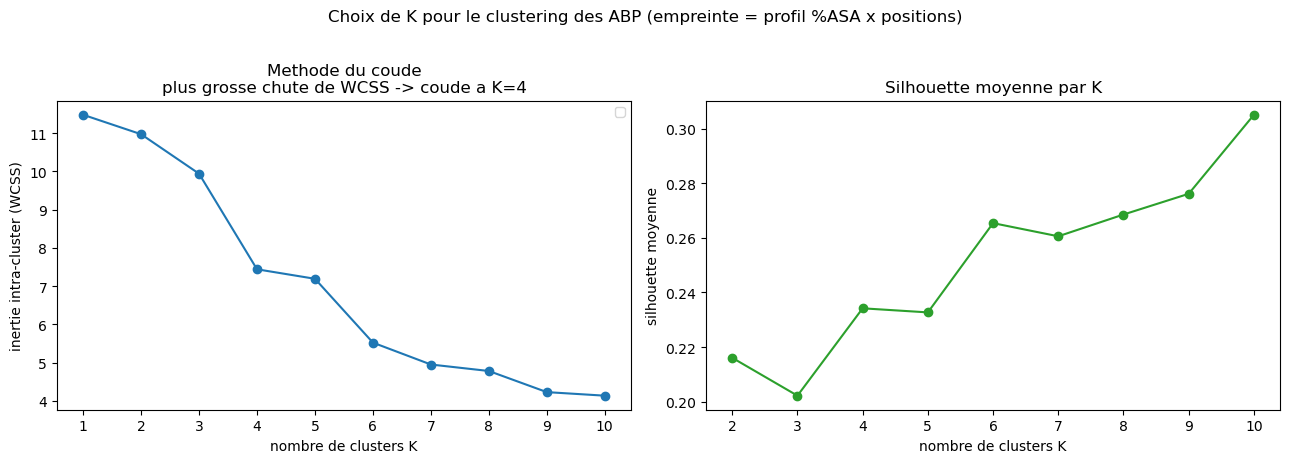

WCSS: [np.float64(11.48), np.float64(10.97), np.float64(9.94), np.float64(7.44), np.float64(7.19), np.float64(5.52), np.float64(4.95), np.float64(4.78), np.float64(4.23), np.float64(4.13)]
silhouette: [None, np.float64(0.216), np.float64(0.202), np.float64(0.234), np.float64(0.233), np.float64(0.265), np.float64(0.261), np.float64(0.269), np.float64(0.276), np.float64(0.305)]
-> K=4 (coude). NB binaire : silhouette faible, clusters desequilibres -> regroupement binaire peu net.


In [14]:
# === Methode du coude (+ silhouette) : choix du nombre de clusters K pour l'empreinte ABP ===
# Meme donnee que la heatmap/PCoA : presence/absence (ASA>0), distance de Jaccard, linkage average.
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage as _lk, fcluster as _fc
_Bp=(pivot.values>0).astype(float)
_De=np.nan_to_num(squareform(pdist(_Bp,metric='jaccard')))
_ne=_De.shape[0]; _Je=np.eye(_ne)-np.ones((_ne,_ne))/_ne
_Ge=-0.5*_Je@(_De**2)@_Je; _ve,_ce=np.linalg.eigh(_Ge); _oe=_ve.argsort()[::-1]; _ve,_ce=_ve[_oe],_ce[:,_oe]
_pv=np.maximum(_ve,0); _embe=_ce[:,:min(8,_ne)]*np.sqrt(_pv[:min(8,_ne)])
_Ze=_lk(_Bp,method='average',metric='jaccard')
def _sile(D,lab):
    s=[]
    for i in range(len(lab)):
        sm=[D[i,j] for j in range(len(lab)) if lab[j]==lab[i] and j!=i]; a=np.mean(sm) if sm else 0
        ot=[np.mean([D[i,j] for j in range(len(lab)) if lab[j]==c]) for c in set(lab) if c!=lab[i]]; b=min(ot) if ot else 0
        s.append(0 if max(a,b)==0 else (b-a)/max(a,b))
    return np.mean(s)
_Ks=list(range(1,11)); _wcss=[]; _silh=[]
for K in _Ks:
    lab=_fc(_Ze,K,criterion='maxclust')
    _wcss.append(sum(((_embe[lab==c]-_embe[lab==c].mean(0))**2).sum() for c in set(lab)))
    _silh.append(_sile(_De,lab) if K>1 else np.nan)
_drops=[_wcss[i]-_wcss[i+1] for i in range(len(_wcss)-1)]
_Kopt=int(np.argmax(_drops))+2   # coude = K juste apres la plus grosse chute de WCSS
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(13,4.5))
ax1.plot(_Ks,_wcss,'o-',color='#1f77b4'); _=0; ax1.set_xlabel('nombre de clusters K'); ax1.set_ylabel('inertie intra-cluster (WCSS)')
ax1.set_title(f"Methode du coude\nplus grosse chute de WCSS -> coude a K={_Kopt}"); ax1.legend(fontsize=9); ax1.set_xticks(_Ks)
ax2.plot(_Ks[1:],_silh[1:],'o-',color='#2ca02c'); ax2.set_xlabel('nombre de clusters K'); ax2.set_ylabel('silhouette moyenne')
ax2.set_title("Silhouette moyenne par K"); ax2.set_xticks(_Ks[1:])
plt.suptitle("Choix de K pour le clustering des ABP (empreinte = profil %ASA x positions)",y=1.02,fontsize=12)
plt.tight_layout(); plt.show()
print('WCSS:',[round(w,2) for w in _wcss]); print('silhouette:',[round(s,3) if not np.isnan(s) else None for s in _silh])
print(f'-> K={_Kopt} (coude). NB binaire : silhouette faible, clusters desequilibres -> regroupement binaire peu net.')


Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


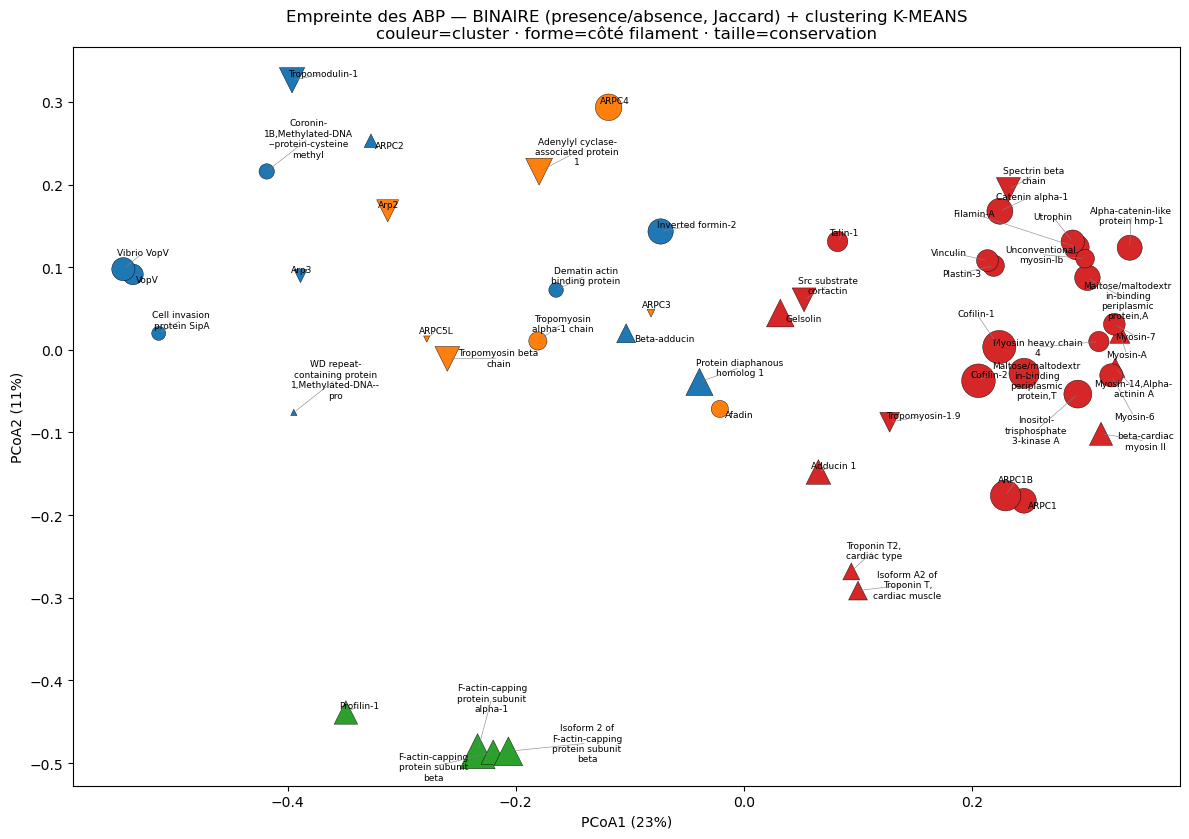

Cluster 1 (n=12): Coronin-1B,Methylated-DNA--protein-cysteine methyl, Cell invasion protein SipA, VopV, Vibrio VopV, Inverted formin-2, Dematin actin binding protein, Arp3, ARPC2, Tropomodulin-1, Protein diaphanous homolog 1, Beta-adducin, WD repeat-containing protein 1,Methylated-DNA--pro

Cluster 2 (n=28): Cofilin-1, Spectrin beta chain, Catenin alpha-1, Myosin-7, Inositol-trisphosphate 3-kinase A, Alpha-catenin-like protein hmp-1, Myosin heavy chain 4, Myosin-6, Talin-1, Filamin-A, Adducin 1, Maltose/maltodextrin-binding periplasmic protein,A, Gelsolin, Plastin-3, Unconventional myosin-Ib, Utrophin, Cofilin-2, ARPC1, Troponin T2, cardiac type, Vinculin, Isoform A2 of Troponin T, cardiac muscle, Myosin-14,Alpha-actinin A, ARPC1B, Src substrate cortactin, Tropomyosin-1.9, Myosin-A, Maltose/maltodextrin-binding periplasmic protein,T, beta-cardiac myosin II

Cluster 3 (n=4): F-actin-capping protein subunit alpha-1, F-actin-capping protein subunit beta, Isoform 2 of F-actin-capping prote

In [15]:
try:
    from adjustText import adjust_text
except Exception:
    def adjust_text(*a, **k): pass
# helper importe depuis abp_analysis (rend la cellule autonome)
import re as _re
def _arp_name(n):
    if 'complex subunit 5-like' in n: return 'ARPC5L'
    mc = _re.search(r'complex subunit (\d+[A-Za-z]?)', n)
    if mc: return 'ARPC' + mc.group(1)
    if _re.match(r'Actin-related protein 3(\b|,|$)', n): return 'Arp3'
    if _re.match(r'Actin-related protein 2(\b|,|$)', n): return 'Arp2'
    return n

# k-means (k=2) + PCA ; couleur=cluster, forme=cote filament (+/-/partout)
from scipy.cluster.vq import kmeans2
from matplotlib.lines import Line2D
from pathlib import Path as _P
_R = _P('..') if _P('../data').exists() else _P('.')

# --- tendance cote filament par ABP (via actin_filament_positions.csv) ---
fil = pd.read_csv(_R/'data/filtered/actin_filament_positions.csv'); c2l = dict(zip(fil['chain'].str.lower(), fil['label']))
_da = pd.read_csv(_R/'data/filtered/filtered_all_data.csv', low_memory=False); _da['s2_actine']=_da['s2_actine'].fillna(False).astype(bool)
_di = pd.read_csv(_R/'data/filtered/details/1.interactions.csv').merge(
    _da[['subunit_1','subunit_2','subunit_2_title','s2_actine']].drop_duplicates(), left_on=['chain_A_id','chain_B_id'], right_on=['subunit_1','subunit_2'], how='left')
_di['s2_actine']=_di['s2_actine'].fillna(False).astype(bool); _di=_di[~_di['s2_actine']].copy()
_di['abp']=_di['subunit_2_title'].fillna('Unknown').str.replace(r'\s*\(.*?\)','',regex=True).str.strip().str[:50].map(_arp_name)
_di['fil']=_di['chain_A_id'].str.lower().map(c2l)
def _simp(l):
    if pd.isna(l): return None
    if l=='+': return '+'          # bout barbe strict
    if l=='-': return '-'          # bout pointe strict
    return 'side'                  # side, +2, +3, -2, -3 -> lateral
_di['grp']=_di['fil'].map(_simp)
# tendance par presence (ensemble des positions), identique a streamlit _pos_border_color :
# + (avec ou sans side) -> barbe ; - (avec ou sans side) -> pointe ; side seul ou les 2 bouts -> lateral
posset=_di.dropna(subset=['grp']).groupby('abp')['grp'].apply(set)
def _tend(s):
    hp='+' in s; hm='-' in s
    if hp and not hm: return '+'
    if hm and not hp: return '-'
    return 'partout'
tendance={a:_tend(posset.get(a,set())) for a in posset.index}
tend_arr=np.array([tendance.get(a,'partout') for a in pivot.index])

# --- BINAIRE : presence/absence (ASA>0) ; distance de Jaccard (= meme regroupement que la heatmap) ---
from scipy.spatial.distance import pdist, squareform
_Bp=(pivot.values>0).astype(float)
_Dj=np.nan_to_num(squareform(pdist(_Bp,metric='jaccard')))
_n=_Dj.shape[0]; _Jc=np.eye(_n)-np.ones((_n,_n))/_n
_G=-0.5*_Jc@(_Dj**2)@_Jc
_val,_vec=np.linalg.eigh(_G); _ord=_val.argsort()[::-1]; _val,_vec=_val[_ord],_vec[:,_ord]
_posv=np.maximum(_val,0); pcs=_vec[:,:2]*np.sqrt(_posv[:2]); ev=_posv/_posv.sum()*100
# clusters = K-MEANS sur l'embedding PCoA binaire (Jaccard), K issu du coude
from scipy.cluster.vq import kmeans2 as _km
K = 4   # <<< NOMBRE DE CLUSTERS (A) — modifie ce chiffre (coude conseille K=4)
_kd=min(6,_n); _emb=_vec[:,:_kd]*np.sqrt(_posv[:_kd])
_best=None
for _sd in range(40):
    _cc,_ll=_km(_emb,K,minit='++',seed=_sd)
    if len(set(_ll))<K: continue
    _ss=((_emb-_cc[_ll])**2).sum()
    if _best is None or _ss<_best[0]: _best=(_ss,_ll)
labels=_best[1]

# --- taille = conservation moyenne de l'interface actine (ponderee par enfouissement) ---
_cdf=pd.read_csv(_R/'data/proteocast/conservation_vs_asa_per_position.csv')
_cmap=dict(zip(_cdf['canon'].astype(int), _cdf['conservation']))
_cvec=np.array([_cmap.get(int(c),np.nan) for c in pivot.columns]); _msk=~np.isnan(_cvec)
_W=pivot.values.astype(float)
_num=(_W[:,_msk]*_cvec[_msk]).sum(1); _den=_W[:,_msk].sum(1)
cons_abp=np.where(_den>0,_num/np.where(_den>0,_den,1),np.nan)   # conservation moyenne ponderee de l'interface
cmin=np.nanmin(cons_abp); cmax=np.nanmax(cons_abp)
_t=(cons_abp-cmin)/(cmax-cmin); sizes=20+620*np.power(np.clip(_t,0,1),2.5); sizes=np.where(np.isnan(sizes),20,sizes)

cols=['#1f77b4','#d62728','#2ca02c','#ff7f0e']; shp={'+':'^','-':'v','partout':'o'}
fig,ax=plt.subplots(figsize=(12,8.5))
for cl in range(K):
    for t,mk in shp.items():
        m=(labels==cl)&(tend_arr==t)
        if m.any(): ax.scatter(pcs[m,0],pcs[m,1],marker=mk,color=cols[cl],s=sizes[m],edgecolor='k',lw=0.3)  # taille = conservation
import textwrap as _tw
_wrapn=lambda s: '\n'.join(_tw.wrap(str(s), 18))  # nom complet, replie a 18 car.
texts=[ax.text(pcs[i,0],pcs[i,1],_wrapn(nm),fontsize=6.5,ha='center') for i,nm in enumerate(pivot.index)]
adjust_text(texts,ax=ax,arrowprops=dict(arrowstyle='-',lw=0.4,color='grey'),
            expand_text=(1.3,1.5),expand_points=(1.4,1.6),force_text=(0.5,0.8),force_points=(0.3,0.5))
sh=[Line2D([0],[0],marker=m,color='grey',ls='',ms=10,label=l) for l,m in [('barbé (+)','^'),('pointé (−)','v'),('partout','o')]]
co=[Line2D([0],[0],marker='s',color=cols[c],ls='',ms=10,label=f'cluster {c+1}') for c in range(K)]
ax.set_xlabel(f'PCoA1 ({ev[0]:.0f}%)'); ax.set_ylabel(f'PCoA2 ({ev[1]:.0f}%)')
ax.set_title('Empreinte des ABP — BINAIRE (presence/absence, Jaccard) + clustering K-MEANS\ncouleur=cluster · forme=côté filament · taille=conservation')
plt.tight_layout(); plt.show()
for cl in range(K):
    print(f'Cluster {cl+1} (n={int((labels==cl).sum())}):', ', '.join(pivot.index[labels==cl])); print()
_cs=pd.Series(cons_abp,index=pivot.index).dropna().sort_values(ascending=False)
print('Conservation interface — top 5 :'); print(_cs.head().round(3).to_string())
print('\nConservation interface — bottom 5 :'); print(_cs.tail().round(3).to_string())

### Comparaison — Option B (continu, corrélation)\n\nMême ABP mais regroupés par **intensité** denfouissement (%ASA continu) au lieu de présence/absence. À comparer avec la PCoA binaire ci-dessus.

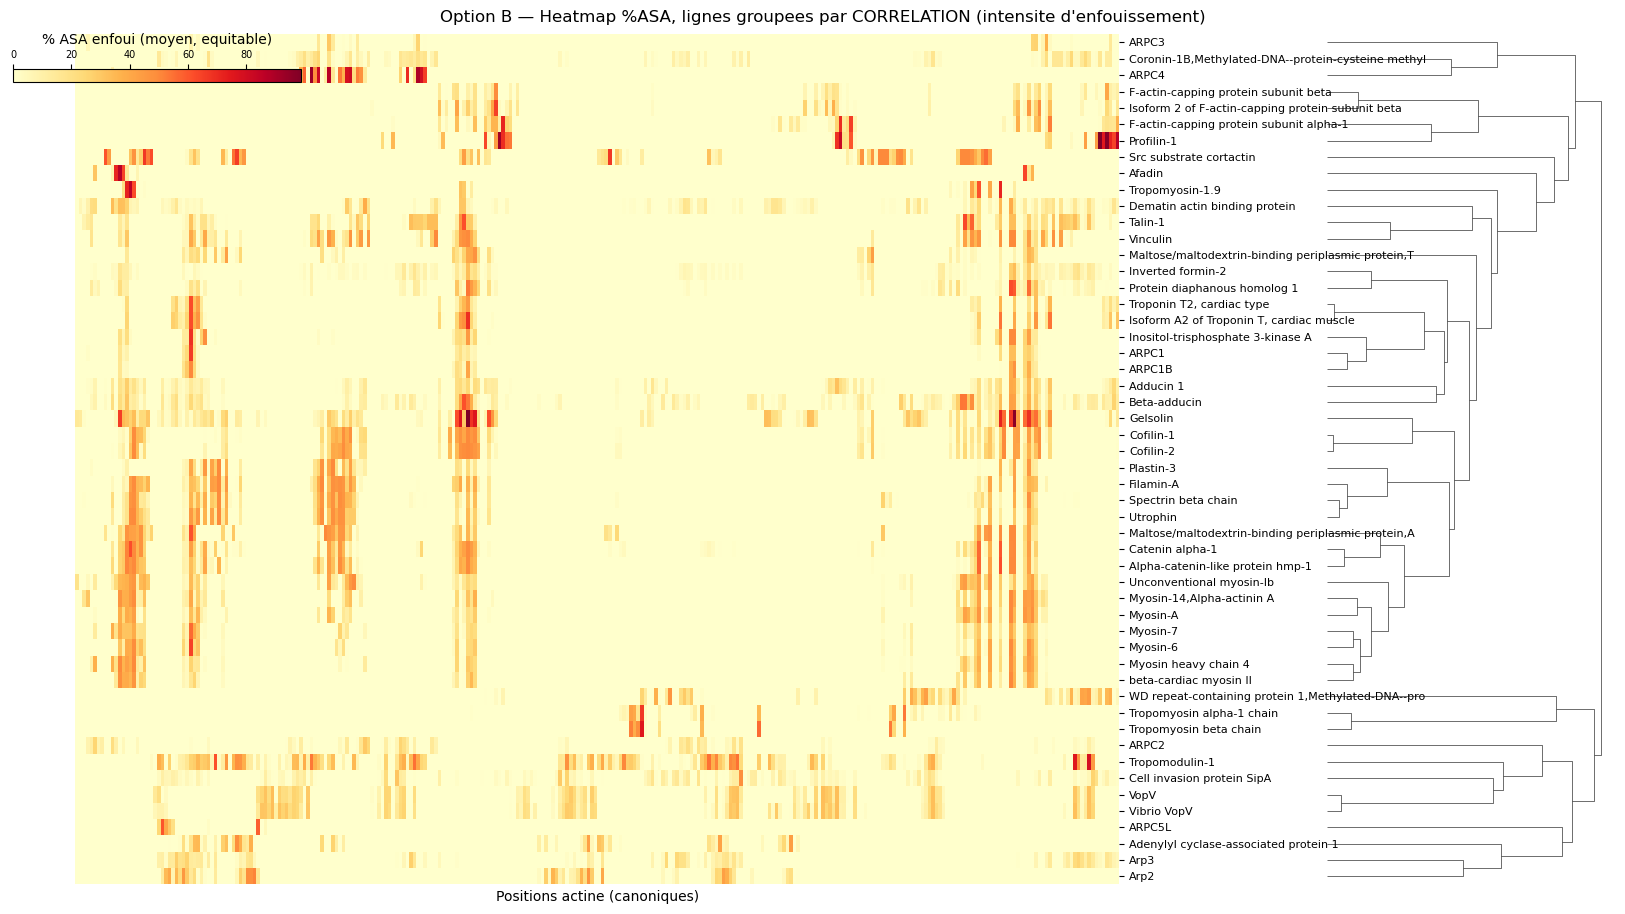

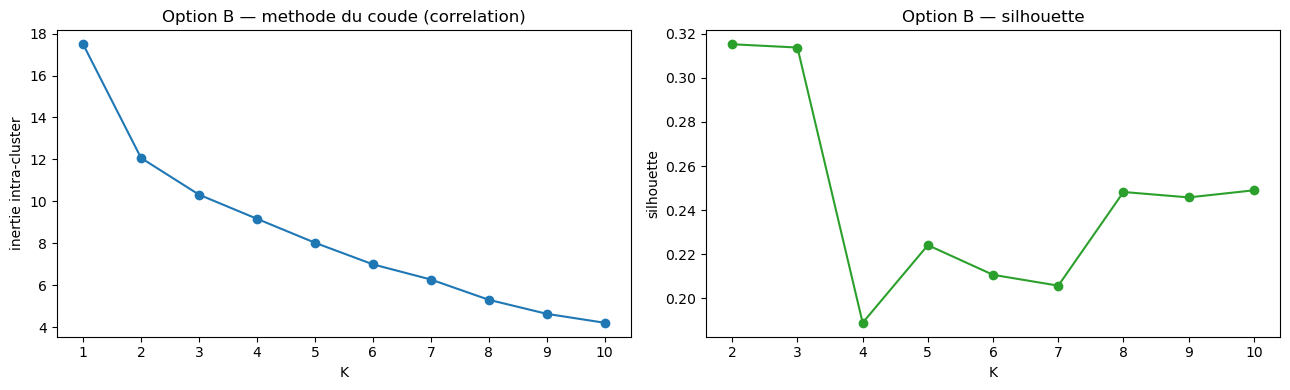

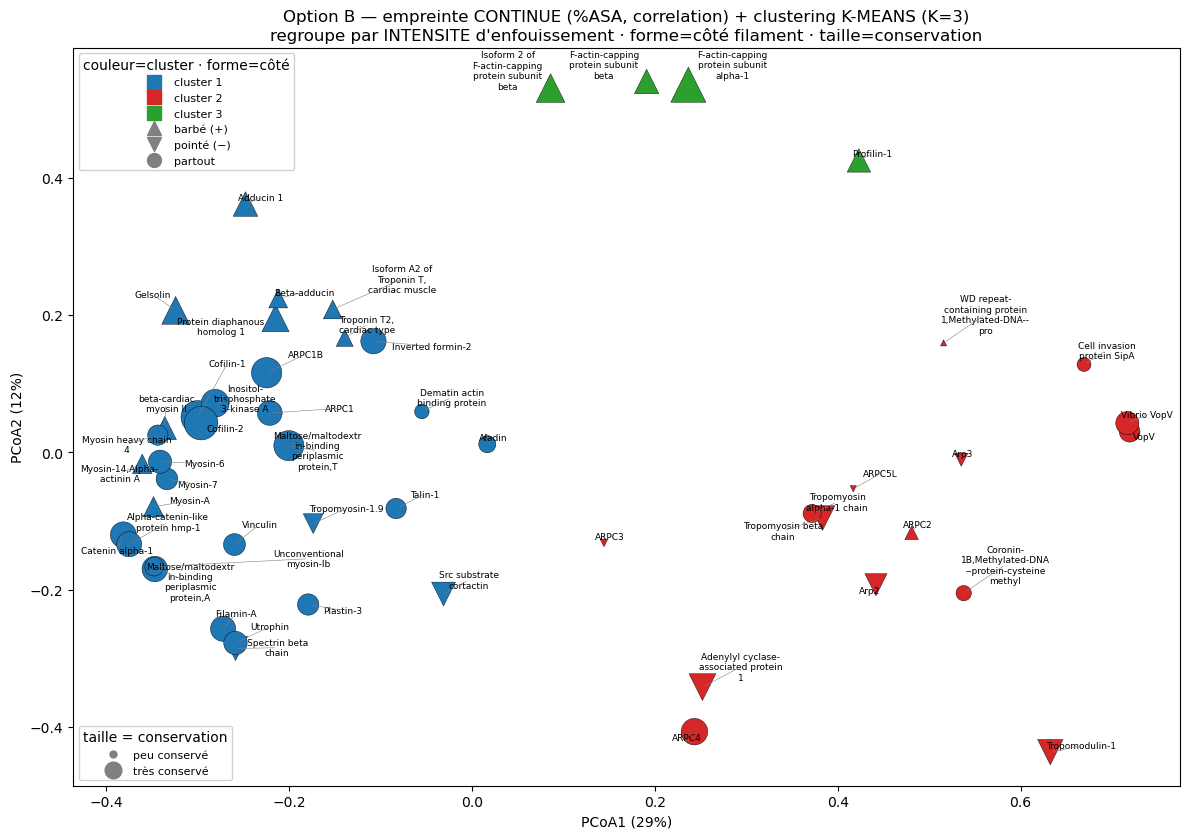

[B kmeans] Cluster 1 (n=33): Cofilin-1, Spectrin beta chain, Inverted formin-2, Catenin alpha-1, Dematin actin binding protein, Myosin-7, Inositol-trisphosphate 3-kinase A, Alpha-
[B kmeans] Cluster 2 (n=15): Coronin-1B,Methylated-DNA--protein-cysteine methyl, Cell invasion protein SipA, Tropomyosin alpha-1 chain, VopV, Vibrio VopV, Arp3, ARPC2, Arp2, Tropo
[B kmeans] Cluster 3 (n=4): F-actin-capping protein subunit alpha-1, F-actin-capping protein subunit beta, Isoform 2 of F-actin-capping protein subunit beta, Profilin-1

B : PCoA1+2 = 41% | k-means sur intensite %ASA. A = memes sites (binaire) ; B = meme intensite (continu).


In [16]:
# === COMPARAISON — Option B : empreinte CONTINUE (%ASA) + heatmap correlation + k-means ===
# Reutilise pivot, tend_arr, sizes, shp, cols, adjust_text des cellules precedentes.
import seaborn as _sns
from scipy.spatial.distance import pdist as _pd2, squareform as _sq2
from scipy.cluster.hierarchy import linkage as _lk2
from scipy.cluster.vq import kmeans2 as _km2
import matplotlib as _mpl
from matplotlib.lines import Line2D

# --- (1) Heatmap CONTINUE, lignes groupees par correlation (= distance de l'option B) ---
_ZBh=_lk2(pivot.values, method='average', metric='correlation')
gB=_sns.clustermap(pivot, cmap='YlOrRd', figsize=(18,9), row_cluster=True, col_cluster=False,
                   row_linkage=_ZBh, dendrogram_ratio=(0.10,0.0), xticklabels=False, cbar_pos=None)
gB.ax_heatmap.set_yticks(np.arange(len(pivot))+0.5)
gB.ax_heatmap.set_yticklabels([pivot.index[i] for i in gB.dendrogram_row.reordered_ind], fontsize=8, rotation=0)
gB.ax_heatmap.yaxis.set_ticks_position('right'); gB.ax_heatmap.yaxis.set_label_position('right')  # noms a DROITE
gB.ax_heatmap.set_ylabel('')   # enlever le label 'abp'
_hp=gB.ax_heatmap.get_position()
gB.ax_heatmap.set_position([_hp.x0, _hp.y0, 0.58, _hp.height])              # retrecit la heatmap -> place pour les noms
gB.ax_row_dendrogram.set_position([0.78, _hp.y0, 0.16, _hp.height]); gB.ax_row_dendrogram.invert_xaxis()  # x=0.78 (position) · 0.16 = LONGUEUR du dendrogramme
gB.ax_heatmap.set_xlabel('Positions actine (canoniques)')
gB.fig.suptitle("Option B — Heatmap %ASA, lignes groupees par CORRELATION (intensite d'enfouissement)",y=1.01,fontsize=12)
# --- barre de couleur (gradient % ASA) ---
_smB=_mpl.cm.ScalarMappable(cmap='YlOrRd', norm=_mpl.colors.Normalize(pivot.values.min(), pivot.values.max()))
_caxB=gB.fig.add_axes([0.05,0.93,0.16,0.014])
gB.fig.colorbar(_smB, cax=_caxB, orientation='horizontal', label='% ASA enfoui (moyen, equitable)')
_caxB.tick_params(labelsize=7); _caxB.xaxis.set_label_position('top'); _caxB.xaxis.set_ticks_position('top')
plt.show()

# --- (2) PCoA correlation + clustering K-MEANS (sur l'embedding) ---
_Db=np.nan_to_num(_sq2(_pd2(pivot.values,metric='correlation')))
_nb=_Db.shape[0]; _Jb=np.eye(_nb)-np.ones((_nb,_nb))/_nb
_Gb=-0.5*_Jb@(_Db**2)@_Jb; _vb,_cb=np.linalg.eigh(_Gb); _ob=_vb.argsort()[::-1]; _vb,_cb=_vb[_ob],_cb[:,_ob]
_pvb=np.maximum(_vb,0); pcsB=_cb[:,:2]*np.sqrt(_pvb[:2]); evB=_pvb/_pvb.sum()*100
# --- coude propre a B (distance correlation) : choisit KB ---
from scipy.cluster.vq import kmeans2 as _km2b
_kdB=min(8,_nb); _embB_all=_cb[:,:_kdB]*np.sqrt(_pvb[:_kdB])
def _silb(D,lab):
    s=[]
    for i in range(len(lab)):
        sm=[D[i,j] for j in range(len(lab)) if lab[j]==lab[i] and j!=i]; a=np.mean(sm) if sm else 0
        ot=[np.mean([D[i,j] for j in range(len(lab)) if lab[j]==cc]) for cc in set(lab) if cc!=lab[i]]; b=min(ot) if ot else 0
        s.append(0 if max(a,b)==0 else (b-a)/max(a,b))
    return np.mean(s)
_KsB=list(range(1,11)); _wB=[]; _sB=[]
for _K in _KsB:
    _bb=None
    for _sd in range(20):
        _cc,_ll=_km2b(_embB_all,_K,minit='++',seed=_sd)
        if len(set(_ll))<_K and _K>1: continue
        _ss=((_embB_all-_cc[_ll])**2).sum()
        if _bb is None or _ss<_bb[0]: _bb=(_ss,_ll)
    _wB.append(_bb[0]); _sB.append(_silb(_Db,_bb[1]) if _K>1 else np.nan)
_dropB=[_wB[i]-_wB[i+1] for i in range(len(_wB)-1)]
KB = 3   # <<< NOMBRE DE CLUSTERS (B) — modifie ce chiffre (coude auto=2, K=3 a du sens bio)
figc,(axe1,axe2)=plt.subplots(1,2,figsize=(13,4))
axe1.plot(_KsB,_wB,'o-',color='#1f77b4'); # (pas de ligne K)
axe1.set_xlabel('K'); axe1.set_ylabel('inertie intra-cluster'); axe1.set_title('Option B — methode du coude (correlation)'); axe1.set_xticks(_KsB)
axe2.plot(_KsB[1:],_sB[1:],'o-',color='#2ca02c'); 
axe2.set_xlabel('K'); axe2.set_ylabel('silhouette'); axe2.set_title('Option B — silhouette'); axe2.set_xticks(_KsB[1:])
plt.tight_layout(); plt.show()
# KB defini par le coude ci-dessus
_kd=min(6,_nb); _embB=_cb[:,:_kd]*np.sqrt(_pvb[:_kd])
_best=None
for sd in range(40):
    cc,ll=_km2(_embB,KB,minit='++',seed=sd)
    if len(set(ll))<KB: continue
    ss=((_embB-cc[ll])**2).sum()
    if _best is None or ss<_best[0]: _best=(ss,ll)
labB=_best[1]
fig,ax=plt.subplots(figsize=(12,8.5))
for cl in range(KB):
    for t,mk in shp.items():
        m=(labB==cl)&(tend_arr==t)
        if m.any(): ax.scatter(pcsB[m,0],pcsB[m,1],marker=mk,color=cols[cl%len(cols)],s=sizes[m],edgecolor='k',lw=0.3)  # taille = conservation
import textwrap as _tw
_wrapn=lambda s: '\n'.join(_tw.wrap(str(s), 18))  # nom complet, replie a 18 car.
texts=[ax.text(pcsB[i,0],pcsB[i,1],_wrapn(nm),fontsize=6.5,ha='center') for i,nm in enumerate(pivot.index)]
adjust_text(texts,ax=ax,arrowprops=dict(arrowstyle='-',lw=0.4,color='grey'),
            expand_text=(1.3,1.5),expand_points=(1.4,1.6),force_text=(0.5,0.8),force_points=(0.3,0.5))
ax.set_xlabel(f'PCoA1 ({evB[0]:.0f}%)'); ax.set_ylabel(f'PCoA2 ({evB[1]:.0f}%)')
from matplotlib.lines import Line2D as _L2
_hsh=[_L2([0],[0],marker=m,color='grey',ls='',ms=10,label=l) for l,m in [('barbé (+)','^'),('pointé (−)','v'),('partout','o')]]
_hcl=[_L2([0],[0],marker='s',color=cols[k%len(cols)],ls='',ms=10,label=f'cluster {k+1}') for k in range(KB)]
_hsz=[_L2([0],[0],marker='o',color='grey',ls='',ms=ss,label=lb) for ss,lb in [(5,'peu conservé'),(12,'très conservé')]]
_lg1=ax.legend(handles=_hcl+_hsh,loc='upper left',fontsize=8,title='couleur=cluster · forme=côté',framealpha=.9)
ax.add_artist(_lg1)
ax.legend(handles=_hsz,loc='lower left',fontsize=8,title='taille = conservation',framealpha=.9)
ax.set_title(f"Option B — empreinte CONTINUE (%ASA, correlation) + clustering K-MEANS (K={KB})\n"
             "regroupe par INTENSITE d'enfouissement · forme=côté filament · taille=conservation")
plt.tight_layout(); plt.show()
for cl in range(KB):
    print(f'[B kmeans] Cluster {cl+1} (n={int((labB==cl).sum())}):', ', '.join(pivot.index[labB==cl])[:150])
print(f'\nB : PCoA1+2 = {evB[0]+evB[1]:.0f}% | k-means sur intensite %ASA. A = memes sites (binaire) ; B = meme intensite (continu).')


### La conservation differe-t-elle entre clusters dempreinte ? (justifie le facteur taille)\n\nLe marqueur = conservation moyenne de linterface ABP. Test : la conservation depend-elle du cluster (option B) ?

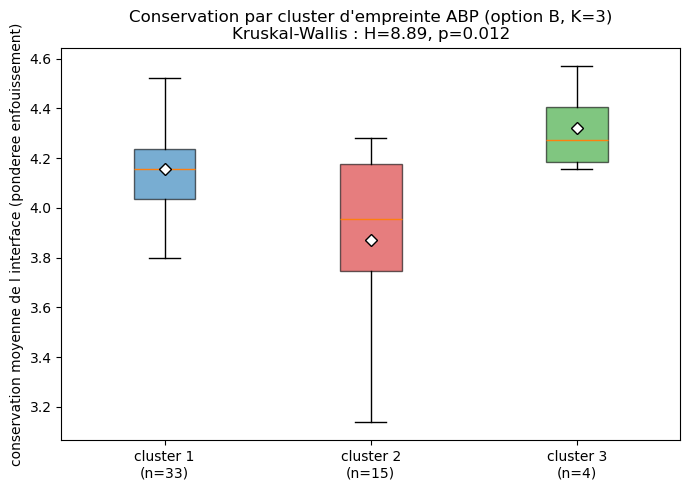

Kruskal-Wallis : H=8.89, p=0.012  -> SIGNIFICATIF
  cluster1 (med=4.16) vs cluster2 (med=3.95) : MW p=0.016
  cluster1 (med=4.16) vs cluster3 (med=4.27) : MW p=0.127
  cluster2 (med=3.95) vs cluster3 (med=4.27) : MW p=0.027

Lecture : le facteur TAILLE (conservation) porte un vrai signal -> a garder.


In [17]:
# === La conservation differe-t-elle entre clusters d'empreinte (B) ? (justifie le facteur taille) ===
from scipy.stats import kruskal, mannwhitneyu
from itertools import combinations
_cv=np.asarray(cons_abp); _lb=np.asarray(labB)
_grps=[_cv[(_lb==k)&~np.isnan(_cv)] for k in range(KB)]
_H,_pk=kruskal(*_grps)
_lblnames={0:'cluster 1',1:'cluster 2',2:'cluster 3',3:'cluster 4'}
fig,ax=plt.subplots(figsize=(7,5))
bp=ax.boxplot(_grps,labels=[f'{_lblnames[k]}\n(n={len(_grps[k])})' for k in range(KB)],
              patch_artist=True,showmeans=True,meanprops=dict(marker='D',mfc='white',mec='k',ms=6))
for b,c in zip(bp['boxes'],cols): b.set_facecolor(c); b.set_alpha(.6)
ax.set_ylabel('conservation moyenne de l interface (ponderee enfouissement)')
ax.set_title(f"Conservation par cluster d'empreinte ABP (option B, K={KB})\nKruskal-Wallis : H={_H:.2f}, p={_pk:.3f}")
plt.tight_layout(); plt.show()
print(f'Kruskal-Wallis : H={_H:.2f}, p={_pk:.3f}'+('  -> SIGNIFICATIF' if _pk<0.05 else '  -> NS'))
for a,b in combinations(range(KB),2):
    print(f'  cluster{a+1} (med={np.median(_grps[a]):.2f}) vs cluster{b+1} (med={np.median(_grps[b]):.2f}) : MW p={mannwhitneyu(_grps[a],_grps[b])[1]:.3f}')
print("\nLecture : le facteur TAILLE (conservation) porte un vrai signal -> a garder.")


52 ABP, 11 descripteurs (agreg. 2 etages : par site -> pondere enfouissement -> moyenne entre sites). Imputes: aucun
Variance PC1+PC2 = 24% + 15% = 40%


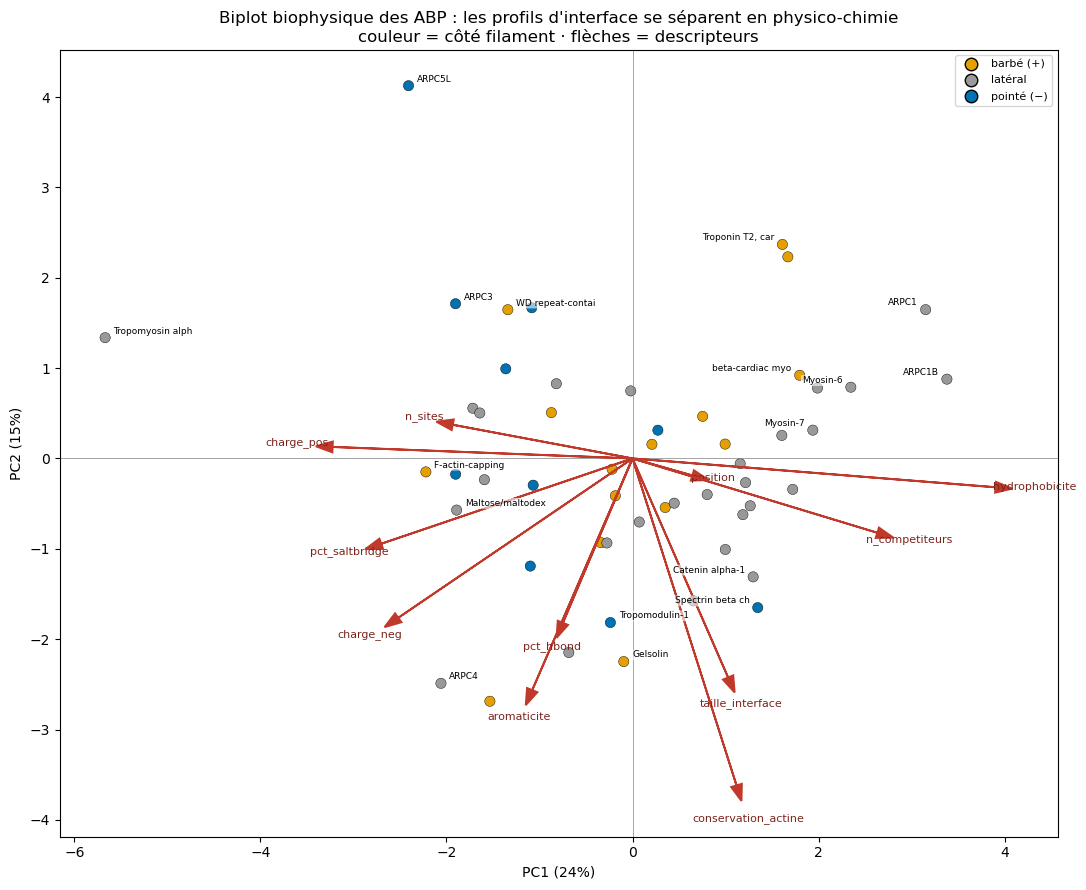

Silhouette k-means k=2 = 0.160  (vs ~0.30 pour la PCA d'empreinte -> ici gradient, pas clusters nets)


In [18]:
# === PCA biophysique (ordination) : 11 descripteurs d'interface cote actine ===
import warnings; warnings.filterwarnings('ignore')
import re as _re
from pathlib import Path as _P
from matplotlib.lines import Line2D
from scipy.spatial.distance import pdist, squareform
_R = _P('..') if _P('../data').exists() else _P('.')

def _arpn(n):
    if 'complex subunit 5-like' in n: return 'ARPC5L'
    mc=_re.search(r'complex subunit (\d+[A-Za-z]?)',n)
    if mc: return 'ARPC'+mc.group(1)
    if _re.match(r'Actin-related protein 3(\b|,|$)',n): return 'Arp3'
    if _re.match(r'Actin-related protein 2(\b|,|$)',n): return 'Arp2'
    return n
_df3=pd.read_csv(_R/'data/filtered/details/3.interface_residues.csv')
_df3['pct']=pd.to_numeric(_df3['buried_ASA_percent'].astype(str).str.replace('%','',regex=False),errors='coerce')
_df3['a2']=pd.to_numeric(_df3['buried_ASA_Å²'].astype(str).str.replace('<0.1','0.05',regex=False),errors='coerce')
_df3['canon']=pd.to_numeric(_df3['residue_number_canon_mafft'],errors='coerce')
_df3=_df3[_df3.canon.notna()&_df3.pct.notna()].copy()
_di=pd.read_csv(_R/'data/filtered/details/1.interactions.csv')
_da=pd.read_csv(_R/'data/filtered/filtered_all_data.csv',low_memory=False)
_pp=pd.read_csv(_R/'data/filtered/proteins_per_pdb.csv'); _ac=set(_pp[_pp.is_actin]['chain'].str.lower())
_homo=set(_di[_di['chain_B_id'].str.lower().isin(_ac)]['interaction_id'])
_het=_di[~_di.interaction_id.isin(_homo)].merge(
    _da[['subunit_1','subunit_2','subunit_2_title','s2_actine','cluster_data_70','s1_binding_site_cluster_data_70']],
    left_on=['chain_A_id','chain_B_id'],right_on=['subunit_1','subunit_2'],how='left').drop_duplicates('interaction_id')
_het=_het[_het['s2_actine'].fillna(False)==False].copy()
_het['abp']=_het['subunit_2_title'].fillna('Unknown').str.replace(r'\s*\(.*?\)','',regex=True).str.strip().str[:50].map(_arpn)
# un "site" = cluster de site de liaison S1 (fallback = cluster_data_70 si manquant)
_het['site']=_het['s1_binding_site_cluster_data_70'].fillna('c70_'+_het['cluster_data_70'].astype(str))
_im=_het.set_index('interaction_id'); _s1=_im['chain_A_id'].str.lower(); _ab=_im['abp']; _st=_im['site']
_dd=_df3[_df3.interaction_id.isin(set(_het.interaction_id))].copy()
_dd['_c']=_dd.interaction_id.map(_s1); _dd=_dd[_dd.chain.str.lower()==_dd._c].copy()   # cote actine
_dd['abp']=_dd.interaction_id.map(_ab); _dd['site']=_dd.interaction_id.map(_st); _dd['canon']=_dd.canon.astype(int)
_cdf=pd.read_csv(_R/'data/proteocast/conservation_vs_asa_per_position.csv'); _cons=dict(zip(_cdf['canon'].astype(int),_cdf['conservation']))
_KD={'A':1.8,'R':-4.5,'N':-3.5,'D':-3.5,'C':2.5,'Q':-3.5,'E':-3.5,'G':-0.4,'H':-3.2,'I':4.5,'L':3.8,'K':-3.9,'M':1.9,'F':2.8,'P':-1.6,'S':-0.8,'T':-0.7,'W':-0.9,'Y':-1.3,'V':4.2}
def _mode(s): m=s.mode(); return m.iloc[0] if len(m) else None
# --- etage 1 : par (abp, site, canon) -> enfouissement moyen de la position dans le site ---
_pos=_dd.groupby(['abp','site','canon']).agg(w=('pct','mean'),a2=('a2','mean'),res=('residue_name',_mode)).reset_index()
_pos['kd']=_pos['res'].map(lambda r:_KD.get(str(r),0.0)); _pos['cons']=_pos['canon'].map(lambda c:_cons.get(int(c),np.nan))
_pos['ispos']=_pos['res'].isin({'R','K'}).astype(float); _pos['isneg']=_pos['res'].isin({'D','E'}).astype(float); _pos['isaro']=_pos['res'].isin({'F','Y','W'}).astype(float)
def _wm(g,col):
    w=g['w'].values; x=g[col].values; m=~np.isnan(x)
    return (w[m]*x[m]).sum()/w[m].sum() if w[m].sum()>0 else np.nan
# --- etage 1bis : par (abp, site) moyennes ponderees enfouissement ; etage 2 : moyenne entre sites ---
_site=_pos.groupby(['abp','site']).apply(lambda g:pd.Series({
    'conservation_actine':_wm(g,'cons'),'hydrophobicite':_wm(g,'kd'),'charge_pos':_wm(g,'ispos'),
    'charge_neg':_wm(g,'isneg'),'aromaticite':_wm(g,'isaro'),'asa_moyen':_wm(g,'w'),'taille_interface':g['a2'].sum()})).reset_index()
F=_site.groupby('abp')[['conservation_actine','hydrophobicite','charge_pos','charge_neg','aromaticite','asa_moyen']].mean()
F['taille_interface']=_site.groupby('abp')['taille_interface'].max()   # la plus grosse interface de l'ABP (pas la moyenne/somme)
# ratios H-bond / pont salin : par site puis moyenne entre sites
_hb=_het.groupby(['abp','site'])[['num_contacts','num_hbonds','num_salt_bridges']].sum().reset_index()
_hb['pct_hbond']=100*_hb['num_hbonds']/_hb['num_contacts']; _hb['pct_saltbridge']=100*_hb['num_salt_bridges']/_hb['num_contacts']
F=F.join(_hb.groupby('abp')[['pct_hbond','pct_saltbridge']].mean())
# position ordinale (aussi utilisee en couleur)
_fil=pd.read_csv(_R/'data/filtered/actin_filament_positions.csv'); _c2l=dict(zip(_fil['chain'].str.lower(),_fil['label']))
_het['fil']=_het['chain_A_id'].str.lower().map(_c2l)
_het['grp']=_het['fil'].map(lambda l: l if l in ('+','-') else ('side' if pd.notna(l) else None))
_ps=_het.dropna(subset=['grp']).groupby('abp')['grp'].apply(set)
F['position']=pd.Series({a:(1.0 if ('+' in _ps.get(a,set()) and '-' not in _ps.get(a,set())) else (-1.0 if ('-' in _ps.get(a,set()) and '+' not in _ps.get(a,set())) else 0.0)) for a in F.index})
F['n_sites']=_het.groupby('abp')['cluster_data_70'].nunique()   # nb de clusters d'interface C70 de l'ABP
_abs1=_het.dropna(subset=['s1_binding_site_cluster_data_70']).groupby('abp')['s1_binding_site_cluster_data_70'].apply(set)
_s1a={}
for a,ss in _abs1.items():
    for s in ss: _s1a.setdefault(s,set()).add(a)
F['n_competiteurs']=pd.Series({a:len({x for s in _abs1.get(a,set()) for x in _s1a.get(s,set())}-{a}) for a in F.index})
F=F[['conservation_actine','hydrophobicite','charge_pos','charge_neg','aromaticite','taille_interface','pct_hbond','pct_saltbridge','position','n_sites','n_competiteurs']]
_miss=F[F.isna().any(axis=1)].index.tolist(); F=F.fillna(F.median(numeric_only=True))
print(f"{len(F)} ABP, {F.shape[1]} descripteurs (agreg. 2 etages : par site -> pondere enfouissement -> moyenne entre sites). Imputes: {_miss if _miss else 'aucun'}")

# z-score + PCA
X=F.values.astype(float); Xz=(X-X.mean(0))/(X.std(0)+1e-9)
Xc=Xz-Xz.mean(0); U,S,Vt=np.linalg.svd(Xc,full_matrices=False); pcs=U[:,:2]*S[:2]; ev=(S**2)/(S**2).sum()*100
print(f"Variance PC1+PC2 = {ev[0]:.0f}% + {ev[1]:.0f}% = {ev[0]+ev[1]:.0f}%")

# couleur = position filament
_pcol={1.0:'#E69F00',-1.0:'#0072B2',0.0:'#999999'}; _plab={1.0:'barbé (+)',-1.0:'pointé (−)',0.0:'latéral'}
_pc=F['position'].map(_pcol).values

# === Biplot : individus (couleur = position) + variables (fleches) ===
cor=np.array([[np.corrcoef(Xz[:,j],pcs[:,k])[0,1] for k in range(2)] for j in range(F.shape[1])])
_f=0.72*np.abs(pcs).max()/np.abs(cor).max()
fig,axb=plt.subplots(figsize=(11,9))
axb.scatter(pcs[:,0],pcs[:,1],c=_pc,s=55,edgecolor='k',lw=.3,zorder=2)
# labels anti-chevauchement : ABP peripheriques, en reservant les emplacements des labels de fleches
_dist=np.hypot(pcs[:,0],pcs[:,1]); _thr=np.percentile(_dist,55)
_xr=pcs[:,0].max()-pcs[:,0].min(); _yr=pcs[:,1].max()-pcs[:,1].min()
_placed=[(cor[j,0]*_f*1.06,cor[j,1]*_f*1.06) for j in range(F.shape[1])]
def _free(x,y,mx=0.06,my=0.045):
    return all(not(abs(x-px)<mx*_xr and abs(y-py)<my*_yr) for px,py in _placed)
for i in np.argsort(-_dist):
    if _dist[i]<_thr: break
    x,y=pcs[i,0],pcs[i,1]
    if not _free(x,y): continue
    _placed.append((x,y)); sd=-1 if x>0 else 1
    axb.annotate(F.index[i][:16],(x,y),fontsize=6.5,zorder=4,ha='right' if sd<0 else 'left',
                 xytext=(6*sd,3),textcoords='offset points',bbox=dict(boxstyle='round,pad=0.1',fc='white',ec='none',alpha=0.6))
for j,nm in enumerate(F.columns):
    axb.arrow(0,0,cor[j,0]*_f,cor[j,1]*_f,color='#c0392b',head_width=.12,length_includes_head=True,lw=1.4,zorder=3)
    axb.annotate(nm,(cor[j,0]*_f*1.06,cor[j,1]*_f*1.06),fontsize=8,color='#7b241c',ha='center',zorder=3)
axb.axhline(0,color='grey',lw=.5); axb.axvline(0,color='grey',lw=.5)
axb.set_xlabel(f'PC1 ({ev[0]:.0f}%)'); axb.set_ylabel(f'PC2 ({ev[1]:.0f}%)')
axb.set_title('Biplot biophysique des ABP : les profils d\'interface se séparent en physico-chimie\ncouleur = côté filament · flèches = descripteurs')
axb.legend(handles=[Line2D([0],[0],marker='o',ls='',mfc=_pcol[k],mec='k',ms=9,label=_plab[k]) for k in [1.0,0.0,-1.0]],loc='best',fontsize=8)
plt.tight_layout(); plt.show()

# silhouette (confirme que c'est une ordination, pas des clusters nets)
from scipy.cluster.vq import kmeans2
_D=squareform(pdist(Xz))
def _sil(D,lab):
    n=len(lab); s=np.zeros(n)
    for i in range(n):
        sm=(lab==lab[i]).copy(); sm[i]=False
        a=D[i,sm].mean() if sm.any() else 0
        b=min((D[i,lab==c].mean() for c in set(lab) if c!=lab[i]),default=0)
        s[i]=0 if max(a,b)==0 else (b-a)/max(a,b)
    return s.mean()
_bb=None
for sd in range(60):
    c,l=kmeans2(Xz,2,minit='++',seed=sd)
    if len(set(l))<2: continue
    ss=((Xz-c[l])**2).sum()
    if _bb is None or ss<_bb[0]: _bb=(ss,l)
print(f"Silhouette k-means k=2 = {_sil(_D,_bb[1]):.3f}  (vs ~0.30 pour la PCA d'empreinte -> ici gradient, pas clusters nets)")

### Variante — ABP biophysique, COEUR (résidus > 25 % ASA)

Même PCA des ABP mais descripteurs d'interface calculés sur les seuls résidus d'actine enfouis > 25 % ASA.

52 ABP, 11 descripteurs (agreg. 2 etages : par site -> pondere enfouissement -> moyenne entre sites). Imputes: aucun
Variance PC1+PC2 = 24% + 15% = 38%


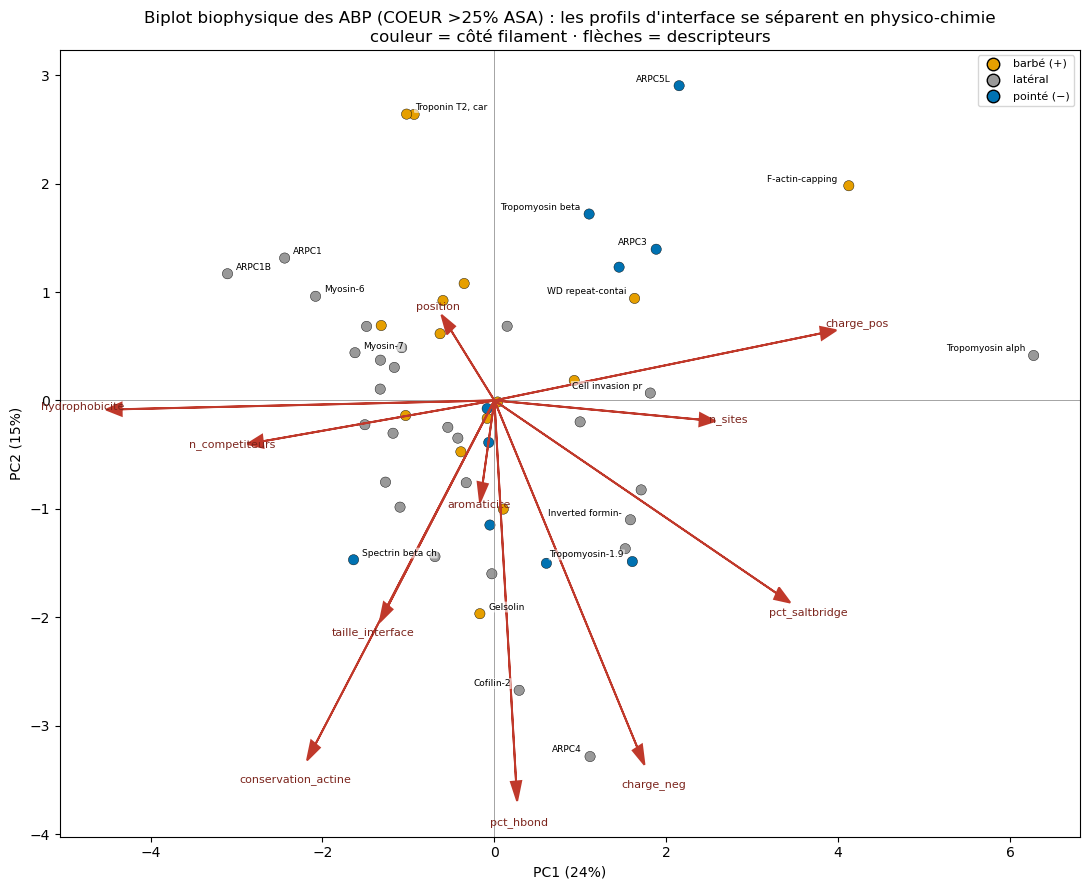

Silhouette k-means k=2 = 0.206  (vs ~0.30 pour la PCA d'empreinte -> ici gradient, pas clusters nets)


In [19]:
# === PCA biophysique (ordination) : 11 descripteurs d'interface cote actine ===
import warnings; warnings.filterwarnings('ignore')
import re as _re
from pathlib import Path as _P
from matplotlib.lines import Line2D
from scipy.spatial.distance import pdist, squareform
_R = _P('..') if _P('../data').exists() else _P('.')

def _arpn(n):
    if 'complex subunit 5-like' in n: return 'ARPC5L'
    mc=_re.search(r'complex subunit (\d+[A-Za-z]?)',n)
    if mc: return 'ARPC'+mc.group(1)
    if _re.match(r'Actin-related protein 3(\b|,|$)',n): return 'Arp3'
    if _re.match(r'Actin-related protein 2(\b|,|$)',n): return 'Arp2'
    return n
_df3=pd.read_csv(_R/'data/filtered/details/3.interface_residues.csv')
_df3['pct']=pd.to_numeric(_df3['buried_ASA_percent'].astype(str).str.replace('%','',regex=False),errors='coerce')
_df3['a2']=pd.to_numeric(_df3['buried_ASA_Å²'].astype(str).str.replace('<0.1','0.05',regex=False),errors='coerce')
_df3['canon']=pd.to_numeric(_df3['residue_number_canon_mafft'],errors='coerce')
_df3=_df3[_df3.canon.notna()&_df3.pct.notna()].copy()
_di=pd.read_csv(_R/'data/filtered/details/1.interactions.csv')
_da=pd.read_csv(_R/'data/filtered/filtered_all_data.csv',low_memory=False)
_pp=pd.read_csv(_R/'data/filtered/proteins_per_pdb.csv'); _ac=set(_pp[_pp.is_actin]['chain'].str.lower())
_homo=set(_di[_di['chain_B_id'].str.lower().isin(_ac)]['interaction_id'])
_het=_di[~_di.interaction_id.isin(_homo)].merge(
    _da[['subunit_1','subunit_2','subunit_2_title','s2_actine','cluster_data_70','s1_binding_site_cluster_data_70']],
    left_on=['chain_A_id','chain_B_id'],right_on=['subunit_1','subunit_2'],how='left').drop_duplicates('interaction_id')
_het=_het[_het['s2_actine'].fillna(False)==False].copy()
_het['abp']=_het['subunit_2_title'].fillna('Unknown').str.replace(r'\s*\(.*?\)','',regex=True).str.strip().str[:50].map(_arpn)
# un "site" = cluster de site de liaison S1 (fallback = cluster_data_70 si manquant)
_het['site']=_het['s1_binding_site_cluster_data_70'].fillna('c70_'+_het['cluster_data_70'].astype(str))
_im=_het.set_index('interaction_id'); _s1=_im['chain_A_id'].str.lower(); _ab=_im['abp']; _st=_im['site']
_dd=_df3[_df3.interaction_id.isin(set(_het.interaction_id))].copy()
_dd['_c']=_dd.interaction_id.map(_s1); _dd=_dd[(_dd.chain.str.lower()==_dd._c)&(_dd['pct']>25)].copy()   # cote actine COEUR >25% ASA
_dd['abp']=_dd.interaction_id.map(_ab); _dd['site']=_dd.interaction_id.map(_st); _dd['canon']=_dd.canon.astype(int)
_cdf=pd.read_csv(_R/'data/proteocast/conservation_vs_asa_per_position.csv'); _cons=dict(zip(_cdf['canon'].astype(int),_cdf['conservation']))
_KD={'A':1.8,'R':-4.5,'N':-3.5,'D':-3.5,'C':2.5,'Q':-3.5,'E':-3.5,'G':-0.4,'H':-3.2,'I':4.5,'L':3.8,'K':-3.9,'M':1.9,'F':2.8,'P':-1.6,'S':-0.8,'T':-0.7,'W':-0.9,'Y':-1.3,'V':4.2}
def _mode(s): m=s.mode(); return m.iloc[0] if len(m) else None
# --- etage 1 : par (abp, site, canon) -> enfouissement moyen de la position dans le site ---
_pos=_dd.groupby(['abp','site','canon']).agg(w=('pct','mean'),a2=('a2','mean'),res=('residue_name',_mode)).reset_index()
_pos['kd']=_pos['res'].map(lambda r:_KD.get(str(r),0.0)); _pos['cons']=_pos['canon'].map(lambda c:_cons.get(int(c),np.nan))
_pos['ispos']=_pos['res'].isin({'R','K'}).astype(float); _pos['isneg']=_pos['res'].isin({'D','E'}).astype(float); _pos['isaro']=_pos['res'].isin({'F','Y','W'}).astype(float)
def _wm(g,col):
    w=g['w'].values; x=g[col].values; m=~np.isnan(x)
    return (w[m]*x[m]).sum()/w[m].sum() if w[m].sum()>0 else np.nan
# --- etage 1bis : par (abp, site) moyennes ponderees enfouissement ; etage 2 : moyenne entre sites ---
_site=_pos.groupby(['abp','site']).apply(lambda g:pd.Series({
    'conservation_actine':_wm(g,'cons'),'hydrophobicite':_wm(g,'kd'),'charge_pos':_wm(g,'ispos'),
    'charge_neg':_wm(g,'isneg'),'aromaticite':_wm(g,'isaro'),'asa_moyen':_wm(g,'w'),'taille_interface':g['a2'].sum()})).reset_index()
F=_site.groupby('abp')[['conservation_actine','hydrophobicite','charge_pos','charge_neg','aromaticite','asa_moyen']].mean()
F['taille_interface']=_site.groupby('abp')['taille_interface'].max()   # la plus grosse interface de l'ABP (pas la moyenne/somme)
# ratios H-bond / pont salin : par site puis moyenne entre sites
_hb=_het.groupby(['abp','site'])[['num_contacts','num_hbonds','num_salt_bridges']].sum().reset_index()
_hb['pct_hbond']=100*_hb['num_hbonds']/_hb['num_contacts']; _hb['pct_saltbridge']=100*_hb['num_salt_bridges']/_hb['num_contacts']
F=F.join(_hb.groupby('abp')[['pct_hbond','pct_saltbridge']].mean())
# position ordinale (aussi utilisee en couleur)
_fil=pd.read_csv(_R/'data/filtered/actin_filament_positions.csv'); _c2l=dict(zip(_fil['chain'].str.lower(),_fil['label']))
_het['fil']=_het['chain_A_id'].str.lower().map(_c2l)
_het['grp']=_het['fil'].map(lambda l: l if l in ('+','-') else ('side' if pd.notna(l) else None))
_ps=_het.dropna(subset=['grp']).groupby('abp')['grp'].apply(set)
F['position']=pd.Series({a:(1.0 if ('+' in _ps.get(a,set()) and '-' not in _ps.get(a,set())) else (-1.0 if ('-' in _ps.get(a,set()) and '+' not in _ps.get(a,set())) else 0.0)) for a in F.index})
F['n_sites']=_het.groupby('abp')['cluster_data_70'].nunique()   # nb de clusters d'interface C70 de l'ABP
_abs1=_het.dropna(subset=['s1_binding_site_cluster_data_70']).groupby('abp')['s1_binding_site_cluster_data_70'].apply(set)
_s1a={}
for a,ss in _abs1.items():
    for s in ss: _s1a.setdefault(s,set()).add(a)
F['n_competiteurs']=pd.Series({a:len({x for s in _abs1.get(a,set()) for x in _s1a.get(s,set())}-{a}) for a in F.index})
F=F[['conservation_actine','hydrophobicite','charge_pos','charge_neg','aromaticite','taille_interface','pct_hbond','pct_saltbridge','position','n_sites','n_competiteurs']]
_miss=F[F.isna().any(axis=1)].index.tolist(); F=F.fillna(F.median(numeric_only=True))
print(f"{len(F)} ABP, {F.shape[1]} descripteurs (agreg. 2 etages : par site -> pondere enfouissement -> moyenne entre sites). Imputes: {_miss if _miss else 'aucun'}")

# z-score + PCA
X=F.values.astype(float); Xz=(X-X.mean(0))/(X.std(0)+1e-9)
Xc=Xz-Xz.mean(0); U,S,Vt=np.linalg.svd(Xc,full_matrices=False); pcs=U[:,:2]*S[:2]; ev=(S**2)/(S**2).sum()*100
print(f"Variance PC1+PC2 = {ev[0]:.0f}% + {ev[1]:.0f}% = {ev[0]+ev[1]:.0f}%")

# couleur = position filament
_pcol={1.0:'#E69F00',-1.0:'#0072B2',0.0:'#999999'}; _plab={1.0:'barbé (+)',-1.0:'pointé (−)',0.0:'latéral'}
_pc=F['position'].map(_pcol).values

# === Biplot : individus (couleur = position) + variables (fleches) ===
cor=np.array([[np.corrcoef(Xz[:,j],pcs[:,k])[0,1] for k in range(2)] for j in range(F.shape[1])])
_f=0.72*np.abs(pcs).max()/np.abs(cor).max()
fig,axb=plt.subplots(figsize=(11,9))
axb.scatter(pcs[:,0],pcs[:,1],c=_pc,s=55,edgecolor='k',lw=.3,zorder=2)
# labels anti-chevauchement : ABP peripheriques, en reservant les emplacements des labels de fleches
_dist=np.hypot(pcs[:,0],pcs[:,1]); _thr=np.percentile(_dist,55)
_xr=pcs[:,0].max()-pcs[:,0].min(); _yr=pcs[:,1].max()-pcs[:,1].min()
_placed=[(cor[j,0]*_f*1.06,cor[j,1]*_f*1.06) for j in range(F.shape[1])]
def _free(x,y,mx=0.06,my=0.045):
    return all(not(abs(x-px)<mx*_xr and abs(y-py)<my*_yr) for px,py in _placed)
for i in np.argsort(-_dist):
    if _dist[i]<_thr: break
    x,y=pcs[i,0],pcs[i,1]
    if not _free(x,y): continue
    _placed.append((x,y)); sd=-1 if x>0 else 1
    axb.annotate(F.index[i][:16],(x,y),fontsize=6.5,zorder=4,ha='right' if sd<0 else 'left',
                 xytext=(6*sd,3),textcoords='offset points',bbox=dict(boxstyle='round,pad=0.1',fc='white',ec='none',alpha=0.6))
for j,nm in enumerate(F.columns):
    axb.arrow(0,0,cor[j,0]*_f,cor[j,1]*_f,color='#c0392b',head_width=.12,length_includes_head=True,lw=1.4,zorder=3)
    axb.annotate(nm,(cor[j,0]*_f*1.06,cor[j,1]*_f*1.06),fontsize=8,color='#7b241c',ha='center',zorder=3)
axb.axhline(0,color='grey',lw=.5); axb.axvline(0,color='grey',lw=.5)
axb.set_xlabel(f'PC1 ({ev[0]:.0f}%)'); axb.set_ylabel(f'PC2 ({ev[1]:.0f}%)')
axb.set_title('Biplot biophysique des ABP (COEUR >25% ASA) : les profils d\'interface se séparent en physico-chimie\ncouleur = côté filament · flèches = descripteurs')
axb.legend(handles=[Line2D([0],[0],marker='o',ls='',mfc=_pcol[k],mec='k',ms=9,label=_plab[k]) for k in [1.0,0.0,-1.0]],loc='best',fontsize=8)
plt.tight_layout(); plt.show()

# silhouette (confirme que c'est une ordination, pas des clusters nets)
from scipy.cluster.vq import kmeans2
_D=squareform(pdist(Xz))
def _sil(D,lab):
    n=len(lab); s=np.zeros(n)
    for i in range(n):
        sm=(lab==lab[i]).copy(); sm[i]=False
        a=D[i,sm].mean() if sm.any() else 0
        b=min((D[i,lab==c].mean() for c in set(lab) if c!=lab[i]),default=0)
        s[i]=0 if max(a,b)==0 else (b-a)/max(a,b)
    return s.mean()
_bb=None
for sd in range(60):
    c,l=kmeans2(Xz,2,minit='++',seed=sd)
    if len(set(l))<2: continue
    ss=((Xz-c[l])**2).sum()
    if _bb is None or ss<_bb[0]: _bb=(ss,l)
print(f"Silhouette k-means k=2 = {_sil(_D,_bb[1]):.3f}  (vs ~0.30 pour la PCA d'empreinte -> ici gradient, pas clusters nets)")

## Comment lire — correspondance figure ⇄ test

- **Fig 1** : flèche `conservation` opposée à `rsa` & `nb familles` (qui sont collées) → enfouissement gouverne, nb de partenaires va avec l'exposition.
- **Fig 2** : le gradient de couleur conservation est l'inverse de celui de rsa/n_fam.
- **Fig 3** : `rsa` est la seule barre forte et stable ; `nb familles`/`nb ABP` **changent de signe** à rsa égal (artefact) ; `hydrophobicité` ≈ 0.

**Phrase défendable :** la conservation d'une position d'actine est gouvernée par son **enfouissement** ;
ni le nombre de partenaires, ni l'hydrophobicité n'ajoutent d'effet propre une fois l'exposition contrôlée.